# Project 2: UFO Sightings - Explainable Phenomena?

***Team**: Sanjiv Narayan, Georgiy Sekretaryuk, David Sherman*\
***GitHubREPO (On UC Berkeley site)**: \https://github.com/UC-Berkeley-I-School/Project2_Narayan_Sekretaryuk_Sherman*

### Proposal Analysis

In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#setting max column width to 20px per column
pd.set_option('max_colwidth', 20)

#reading nuforc file and secondary datasets
nuforc_events = pd.read_csv('nuforc_events.csv')
airports = pd.read_csv('airports.csv')
military_bases = pd.read_csv('MilitaryBases.csv')
space_launch_data = pd.read_csv('space_launch_data.csv')

## **DATA CLEANING**
### Data Cleaning Steps

- Below, we list the steps we took to clean each dataset.

### Data Cleaning Assumptions

- Each dataset lists the assumptions we made in data cleaning
    - Principles that we applied for the dataset, focused on our stated questions.
    - Variables removed
    - Data substituted/removed/reclassified
    
### Final Assumptions (logic leading to each assumption is detailed in sections below).
**National UFO**
1. Year was cleaned. We kept events from 1974 onwards, when NUFORC was created. Prior events were uploaded to NUFORC but were less robust and/or validated.  
2. In an interim analysis, we inspected events from the beginning of the record - 1061!  This was a typo and was 1961. Others dated from the 1700s and were not typos - one record was from Thomas Jefferson, others from London papers in the 1700 and 1800s. However, these events were of course less validated. Also, the URL https: were unloadable so that we could not verify the tenacity of these reports.  
3. Thus, on 11/29/2022 we excluded reports earlier than 1974. In fact, because the bulk of sightings have been after this time, the overall results were actually not very different by removing prior to 1973.
4. The data for month, hour, minute were mostly robust and did not need to be cleaned. The sightings ranged from 12584 in July to 6378 in February. Most sightings were in June, July, August. Least sightings were in Feb, March, April, May.
5. We created a new variable 'Date' in datetime format MM/DD/YY.
6. 11/26/22. We included only locations defined in 50 U.S. States, and D.C. We removed 13 Canadian provinces and other locations.
**Space Launch**
1. Fixed Date format to be comparable across datasets. Dates available 1990 - 2022.
2. We removed duplicated date-entries, taking the first listed row, and assume that this did not remove critical information.
3. 11/29/2022. We removed non-US launches, even though some could be viewed from HI or Guam, on the basis that they are less well validated.
4. Most launches were from Florida, followed by California. A few were from Hawaii.
**Military Bases**
1. All bases were in the U.S. or its territories. We kept U.S. territories (e.g. Guam, Puerto Rico). Future project expansions could cut these.
2. We renamed all state text names to their symbols.
3. We cleaned the last 3 columns - NaN and no data dictionary to interpret them.
**Airports**
1. We kept only airports in the U.S. or its territories (Guam, Puerto Rico) 
2. We will ignore airports from other countries or jurisdictions.

For all datasets, we created new columns City_State where possible to eliminate the possibility of examining same-named cities in different states.

### *National UFO Reporting Center (nuforc_events) Cleaning*

In [3]:
nuforc_events.head(5)

,Event_Time,Event_Date,Year,Month,Day,Hour,Minute,City,State,Shape,Duration,Summary,Event_URL
0,2017-04-20T14:15...,2017-04-20,2017.0,4.0,20.0,14.0,15.0,Palmyra,NJ,Other,5 minutes,I observed an ai...,http://www.nufor...
1,2017-04-20T04:56...,2017-04-20,2017.0,4.0,20.0,4.0,56.0,Bridgeview,IL,Light,20 seconds,"Bridgeview, IL, ...",http://www.nufor...
2,2017-04-19T23:55...,2017-04-19,2017.0,4.0,19.0,23.0,55.0,Newton,AL,Triangle,5 seconds,Silent triangle ...,http://www.nufor...
3,2017-04-19T23:50...,2017-04-19,2017.0,4.0,19.0,23.0,50.0,Newton,AL,Triangle,5-6 minutes,My friend and I ...,http://www.nufor...
4,2017-04-19T23:29...,2017-04-19,2017.0,4.0,19.0,23.0,29.0,Denver,CO,Light,1 hour,Moved slow but m...,http://www.nufor...


In [4]:
nuforc_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110265 entries, 0 to 110264
Data columns (total 13 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Event_Time  108575 non-null  object 
 1   Event_Date  110012 non-null  object 
 2   Year        110012 non-null  float64
 3   Month       110012 non-null  float64
 4   Day         110163 non-null  float64
 5   Hour        108685 non-null  float64
 6   Minute      108677 non-null  float64
 7   City        110036 non-null  object 
 8   State       101961 non-null  object 
 9   Shape       106790 non-null  object 
 10  Duration    106106 non-null  object 
 11  Summary     110229 non-null  object 
 12  Event_URL   110265 non-null  object 
dtypes: float64(5), object(8)
memory usage: 10.9+ MB


**Comments on nuforc_events dataset**
1. 110265 entries, 13 rows
2. Year, Month, Day, Hour, Minute are floats, not dt type
3. City, State, Shape, Duration, Summary, Event_URL are all string

**Years has errors**
Minimum is 1061 (before Battle of Hastings!). Should be 1961. 
There are 56 entries before 1940 (see two cells below). Some have missing data.

In [5]:
nuforc_events = nuforc_events[nuforc_events['Year'] != 'http://www.nuforc.org/webreports/053/S53649.html']
nuforc_events['Year'] = nuforc_events['Year'].astype(float)

In [6]:
nuforc_events['Year'].describe()

count    110012.000000
mean       2005.569502
std          11.564502
min        1061.000000
25%        2002.000000
50%        2008.000000
75%        2013.000000
max        2017.000000
Name: Year, dtype: float64

In [7]:
nuforc_events[nuforc_events['Year'] < 1974].count()

Event_Time    2975
Event_Date    3123
Year          3123
Month         3123
Day           3123
Hour          2975
Minute        2975
City          3112
State         2842
Shape         3015
Duration      3002
Summary       3121
Event_URL     3123
dtype: int64

In [8]:
nuforc_events[nuforc_events['Year'] < 1940].sort_values(by = 'Year', ascending=True).head()

,Event_Time,Event_Date,Year,Month,Day,Hour,Minute,City,State,Shape,Duration,Summary,Event_URL
110011,1061-12-31T22:00...,1061-12-31,1061.0,12.0,31.0,22.0,0.0,Williston,ND,Formation,30 mins,Winter of 61-62 ...,http://www.nufor...
110010,1400-06-30T00:00...,1400-06-30,1400.0,6.0,30.0,0.0,0.0,Myers Spring Canyon,TX,Circle,NaN,What I have is a...,http://www.nufor...
110009,1561-04-14T08:00...,1561-04-14,1561.0,4.0,14.0,8.0,0.0,Nurnburg (Germany),NaN,Cylinder,30 nins,I would think th...,http://www.nufor...
110008,NaN,1615-07-18,1615.0,7.0,18.0,NaN,NaN,London (England),NaN,NaN,10 minutes,Watching air cra...,http://www.nufor...
110007,1762-12-11T21:00...,1762-12-11,1762.0,12.0,11.0,21.0,0.0,"Lulworth, Dorset...",NaN,NaN,>1 minute,Reported in a Lo...,http://www.nufor...


In [9]:
#probing these events. Remove # to see details.
#nuforc_events[nuforc_events['Year'] == 1061] #should be 1961
#nuforc_events[nuforc_events['Year'] == 1400] #Date Error - clearly modern era.
#nuforc_events[nuforc_events['Year'] == 1790] #Likely meteor - "stench of burning sulpher"
#nuforc_events[nuforc_events['Year'] == 1800] #Thomas Jefferson report
nuforc_events[nuforc_events['Year'] == 1910]

,Event_Time,Event_Date,Year,Month,Day,Hour,Minute,City,State,Shape,Duration,Summary,Event_URL
109986,1910-06-01T15:00...,1910-06-01,1910.0,6.0,1.0,15.0,0.0,Wills Point,TX,Cigar,2 minutes,Cigar shaped obj...,http://www.nufor...
109987,1910-05-28T21:00...,1910-05-28,1910.0,5.0,28.0,21.0,0.0,Solon,ME,Unknown,don't know,entry in my grea...,http://www.nufor...
109988,NaN,1910-01-01,1910.0,1.0,1.0,NaN,NaN,Kirksville (near),MO,Disk,Minutes,Historical sight...,http://www.nufor...


**Detailed Year Observations**
1. Some early events are intriguing, such as the report from 1800 by Thomas Jefferson, or the report from a London Paper in 1762. Some of these could be meteors (e.g. 1790 "Slow Moving Fireball, stench of burning sulpher"). 
2. However, URLs were unloadable http addresses, making it difficult to analyze or verify these reports.
3. Reports from 1900s onwards are likely more credible:
- 1906, "oldest professional photo of a UFO object from Wien observatory".
- 1910,"watching the comet zig-zaging in the sky.

**Year Assumptions** 
1. We elected to keep events from 1974 onwards. This leaves 106889 entries.
2. Future projects could open this date range or further restrict it, depending on application and the date range of secondary datasets.
**Done and verified below. Added to overall assumptions above.**

In [10]:
nuforc_events = nuforc_events[nuforc_events['Year'] >= 1974]
nuforc_events[nuforc_events['Year'] < 1974].count()
nuforc_events.count()

Event_Time    105600
Event_Date    106889
Year          106889
Month         106889
Day           106889
Hour          105600
Minute        105600
City          106682
State          98919
Shape         103548
Duration      102896
Summary       106855
Event_URL     106889
dtype: int64

**Months, OK (range 1-12)** 
The sightings ranged from 12584 in July to 6378 in February. Most sightings were in June, July, August. Least sightings were in Feb, March, April, May

In [11]:
nuforc_events['Month'].value_counts(dropna=False).sort_values(ascending=False)

7.0     12584
8.0     11314
9.0     10392
6.0     10198
10.0     9958
11.0     9341
1.0      7617
12.0     7563
3.0      7230
5.0      7163
4.0      7151
2.0      6378
Name: Month, dtype: int64

**Time (hour, minute)**
- No adjustments or cleaning needed.
- Hour was OK, in range 00-23. There were few NaNs (1289/108000). We did not exclude these, since hour may not matter for several analyses.
- Minute was mostly OK - 1289 NaN. Decided against cleaning/removing those because may not be critical to all analyses.

In [12]:
nuforc_events['Hour'].value_counts(dropna=False)

21.0    15358
22.0    14479
20.0    11466
23.0    10568
19.0     8070
0.0      5505
18.0     5467
1.0      4198
17.0     3278
2.0      3026
3.0      2620
5.0      2187
16.0     2094
4.0      2059
15.0     1771
12.0     1762
6.0      1681
13.0     1677
14.0     1651
10.0     1529
11.0     1525
NaN      1289
9.0      1287
7.0      1259
8.0      1083
Name: Hour, dtype: int64

In [13]:
#Assessing how many Minutes were Nan - 1289?
nuforc_events[nuforc_events['Minute'].isna()].count()

Event_Time       0
Event_Date    1289
Year          1289
Month         1289
Day           1289
Hour             0
Minute           0
City          1247
State         1030
Shape         1001
Duration       879
Summary       1284
Event_URL     1289
dtype: int64

**Convert Month, Day, Year to datetime format**
- We create a new column variable 'Date' in same format as Dave created to enable comparisons to secondary datasets e.g. Space Launch 
- Gents - we can change this
- We dropped 'Event_Time', 'Event_Date', 'Year', 'Month', 'Day'

In [14]:
# Create datatime format. Drop other date variables

nuforc_events['Date'] = pd.to_datetime({'year': nuforc_events['Year'], 'month': nuforc_events['Month'],'day': nuforc_events['Day']}).dt.strftime('%m/%d/%y')
nuforc_events.drop(['Event_Time', 'Event_Date', 'Year', 'Month', 'Day'], axis=1, inplace=True)
nuforc_events.head()

,Hour,Minute,City,State,Shape,Duration,Summary,Event_URL,Date
0,14.0,15.0,Palmyra,NJ,Other,5 minutes,I observed an ai...,http://www.nufor...,04/20/17
1,4.0,56.0,Bridgeview,IL,Light,20 seconds,"Bridgeview, IL, ...",http://www.nufor...,04/20/17
2,23.0,55.0,Newton,AL,Triangle,5 seconds,Silent triangle ...,http://www.nufor...,04/19/17
3,23.0,50.0,Newton,AL,Triangle,5-6 minutes,My friend and I ...,http://www.nufor...,04/19/17
4,23.0,29.0,Denver,CO,Light,1 hour,Moved slow but m...,http://www.nufor...,04/19/17


**Location (City, State) observations**

- 70 states were listed in the original dataset.
- Some were duplicates with Upper/Lower cases. **We fixed this using .str.upper().** This eliminated two duplicates.
- We created lists of U.S. States and Canadian provinces ("used_states": 64 including DC and Canadian Provinces).  There were 8465 NaN entries outside used_states.
- Most NaN (outside used_states) were in other countries e.g. UK, Japan, France. A few should have been in used_states but were miscoded (e.g. #197, Greater Atlanta, NaN; Burbank, NaN, #3262 Waterton Canada, NaN), and a few could be included depending on our definitions of U.S. dependencies e.g. #3576 San Juan Puerto Rico.
- **After meetings over Thanksgiving, we decided to include only locations defined in U.S. states.** Done and verified.
- 51/51 states (50+ D.C.) were represented. **There are now 94348 entries** 
- Future studies can easily re-explore Canadian provinces since that list is already created.  Those studies could also may go back and use regex to explore NaNs to find cities or States in US and re-insert them. This is likely a small number.

In [15]:
pd.set_option('display.max_rows', 10)
nuforc_events['State'].value_counts()

CA    12286
FL     5827
WA     5390
TX     4534
NY     4205
      ...  
YT       20
YK        7
Fl        4
VI        1
Ca        1
Name: State, Length: 70, dtype: int64

In [16]:
nuforc_events['State'] = nuforc_events['State'].str.upper()

states = [ 'AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA',
           'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME',
           'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM',
           'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX',
           'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY']
provinces = ['AB','BC','MB','NB','NL','NT','NS','NU','ON','PE','QC','SK','YT']
used_states = states + provinces
nuforc_events[~nuforc_events['State'].isin(states)].head(5)

,Hour,Minute,City,State,Shape,Duration,Summary,Event_URL,Date
5,21.0,45.0,Cobourg (Canada),ON,Light,4 minutes,"Two ""satellites""...",http://www.nufor...,04/19/17
9,20.0,10.0,Chiba City (Japan),NaN,Unknown,3 seconds,I saw a fast pre...,http://www.nufor...,04/19/17
23,16.0,0.0,Bermuda & Florid...,NaN,Cone,5 minutes,Strange phenomen...,http://www.nufor...,04/18/17
32,21.0,30.0,Ropar (Punjab; I...,NaN,Other,1:30,"me,my wife and o...",http://www.nufor...,04/17/17
54,20.0,30.0,London (Enfield)...,NaN,Circle,35-60 seconds,Bright Red UFO o...,http://www.nufor...,04/16/17


In [17]:
#only include events from locations in used_states
nuforc_events = nuforc_events[nuforc_events['State'].isin(states)]
nuforc_events['State'].value_counts()

CA    12287
FL     5831
WA     5390
TX     4534
NY     4205
      ...  
DE      279
WY      278
SD      272
ND      179
DC      127
Name: State, Length: 51, dtype: int64

In [18]:
nuforc_events.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 94348 entries, 0 to 106888
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Hour       93370 non-null  float64
 1   Minute     93370 non-null  float64
 2   City       94253 non-null  object 
 3   State      94348 non-null  object 
 4   Shape      91474 non-null  object 
 5   Duration   90986 non-null  object 
 6   Summary    94315 non-null  object 
 7   Event_URL  94348 non-null  object 
 8   Date       94348 non-null  object 
dtypes: float64(2), object(7)
memory usage: 7.2+ MB


**Duration Assumptions**

- The initial assumption for duration is that we will only use cells where we have data that is in a (number, time) format for the duration type. 
- All time formats will be converted to minutes to simplify analysis.
- Duration cells in the following formats will be filtered out of our analysis:
    - ranges of numbers
    - text ranges
    - dscription of time
    - approximate time events

In [19]:
# if: hr/hrs/hours/hour -> multiply by 60
# if: m/min/minute/minutes -> leave as is
# if: s/sec/second/seconds -> divide by 60

def time_calc(input_df):

    """This functions cycles through each item. If the first item is an int only, save it to item0. If first item is not in it, pass for now. If second item is in one of the 3 time format lists (min, hrs, sec lists), return appropriate multipler to item1. If second item not recognzed, pass for now. In the end, multiply items. Append to dataframe and return dataframe with appended numbers."""

    numbers ={"one":1, "two":2, "three":3, "four":4, "five":5, "six":6, "seven":7, "eight":8, "nine":9, "ten":10}

    min = ["minutes", "min", "minute"]
    sec = ["sec", "secs", "second", "seconds"]
    hrs = ["hr", "hrs", "hour"]
    day = ["day", "days"]
    Converted_Duration_min = []

    for item in input_df['Duration']:
        item0, item1 = 0,0

        # print("INPUT", input_df['Duration'])
        # print("TEST ITEM", item, ":0:",item)
        try:
            split_item = item.split(" ")
        except:
            split_item = ['0','hrs']   
        # print("Splitting the item", split_item)
        
        # print("SPLIT ITEM left:", split_item[0])
        # try:
            # print("SPLIT ITEM right:", split_item[1])
        # except:
        #     pass

        #TESTING INPUTS
        try:
            if type(int(split_item[0])) == int:
                # print(split_item[0]," is INT!")
                item0 = int(split_item[0])
        except:
            pass
            # Catch all time format in X:XX
            # if ':' in str(split_item[0]):
            #     try:
            #         print("Item0 is", split_item[0])
            #         item0 = int(split_item[0].split(":")[0]) + int(split_item[0].split(":")[1])/60
            #         print(item0)
                # except:
                #     pass

        try:

            if type(str(split_item[1])) == str:
                # print(split_item[1], " is STR!")
                if any(word in str(split_item[1]) for word in min):
                    item1 = 1
                if any(word in str(split_item[1]) for word in hrs):
                    item1 = 60
                if any(word in str(split_item[1]) for word in sec):
                    item1 = 1/60   
                if any(word in str(split_item[1]) for word in day):
                    item1 = 1440
        except:
            pass
        
        # print("Adding,", item0, item1, item0*item1)
        Converted_Duration_min.append(item0*item1)

    input_df['Converted_Duration_min'] = Converted_Duration_min

    return input_df

nuforc_events_duration = time_calc(nuforc_events)

In [113]:
nuforc_events = nuforc_events_duration
nuforc_events_duration['Converted_Duration_min'].describe()

count    94348.000000
mean        13.159823
std        245.874691
min       -360.000000
25%          0.000000
50%          0.333333
75%          5.000000
max      43200.000000
Name: Converted_Duration_min, dtype: float64

### *Space Launch Data Cleaning* 

**Date**
- David S first pass by weekend of 11/18/22. SN subsequent edits 11/22/22. Fixed date formatting. Renamed 'Site' as 'State' for comparison across datasets

**Location**
- 75 launches were outside <states>. 
- All were in AU, NZ, 'MH', or 'Pacific Ocean', and could potentially be seen by certain observers in nuforc_events, e.g. HI.
- Decision 11/25/22 to remove all non-US locations to avoid conflicts.

In [22]:
# 1) Fix the date formatting. 
space_launch_data['Fixed Data'] = pd.to_datetime(space_launch_data['Fixed Data']).dt.strftime('%m/%d/%y')
space_launch_data.rename(columns = {'Fixed Data':"Date"}, inplace = True)
space_launch_data['Date'].describe()

count          494
unique         481
top       08/04/22
freq             3
Name: Date, dtype: object

In [23]:
# 2) We are left with 494 records, of which 481 are unique. We viewed the 13 duplicates
space_launch_data[space_launch_data['Date'].duplicated()]

,Date,New Date,Payload,Vehicle,Company,Site
7,09/03/20,NaN,Starlink v1.0-11,Falcon 9,Space Exploratio...,FL
49,10/05/22,NaN,Crew-5,Falcon 9,Space Exploratio...,FL
154,05/15/21,NaN,"F20 ""Running out...",Electron,Rocket Lab Global,NZ
213,06/30/21,NaN,Flight 3,LauncherOne (L1),"Virgin Orbit, LLC",CA
242,06/13/20,NaN,Big Ben,Electron,Rocket Lab Global,NZ
...,...,...,...,...,...,...
394,12/15/20,NaN,Flight 17 / SARd...,Electron,Rocket Lab Global,NZ
411,08/04/22,NaN,NS-22/A2,New Shepard System,Blue Origin,TX
412,08/04/22,NaN,"F29 NROL-199 (""A...",Electron,Rocket Lab Global,NZ
417,08/30/20,NaN,SAOCOM-1B,Falcon 9,Space Exploratio...,FL


In [24]:
#Drop column 'New Date'
space_launch_data.drop('New Date', axis=1)
#Remove the 13 duplicates, leaving us with 481
space_launch_data.drop_duplicates('Date', inplace=True)
space_launch_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 481 entries, 0 to 493
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      481 non-null    object
 1   New Date  6 non-null      object
 2   Payload   479 non-null    object
 3   Vehicle   481 non-null    object
 4   Company   481 non-null    object
 5   Site      480 non-null    object
dtypes: object(6)
memory usage: 26.3+ KB


In [25]:
#rename 'Site' to 'State'. Seventy (70) are not in states
space_launch_data.rename(columns = {'Site':"State"}, inplace = True)
space_launch_data[~space_launch_data['State'].isin(states)].count()

Date        70
New Date     0
Payload     70
Vehicle     70
Company     70
State       69
dtype: int64

In [26]:
#View seventy (70) not in used_states. All in AU, NZ, 'MH', or 'Pacific Ocean'
#Because These launches could be seen by certain observers in nuforc_events, we did not remove them.
space_launch_data[~space_launch_data['State'].isin(states)].head(10)

,Date,New Date,Payload,Vehicle,Company,State
11,09/28/08,NaN,Payload Mass Sim...,Falcon 1,Space Exploratio...,MH
14,09/24/11,NaN,Atlantic Bird 7,Zenit-3SL,Energia Logistic...,Pacific Ocean
15,09/24/08,NaN,Galaxy 19,Zenit-3SL,Sea Launch Limit...,Pacific Ocean
28,09/15/22,NaN,"F30 ""The Owl Spr...",Electron,Rocket Lab Global,NZ
37,10/09/00,NaN,HETE II,Pegasus,Orbital ATK,MH
38,10/09/99,NaN,DIRECTV 1R,Zenit-3SL,Sea Launch Limit...,Pacific Ocean
42,10/07/22,NaN,"F31 ""It Argos Up...",Electron,Rocket Lab Global,NZ
56,10/30/06,NaN,XM Radio 4,Zenit-3SL,Sea Launch Limit...,Pacific Ocean
58,10/29/01,NaN,HyShot 1,Terrier-Orion,Astrotech,AU
59,10/28/20,NaN,Flight 15/Papa1 ...,Electron,Rocket Lab Global,NZ


In [27]:
#We removed launch data from outside U.S.
space_launch_data=space_launch_data[space_launch_data['State'].isin(states)]
space_launch_data['State'].value_counts()

FL    257
CA     81
TX     23
VA     23
NM     18
AK      7
HI      2
Name: State, dtype: int64

In [28]:
#Asking question - why are UFO sightings common in Seattle - is it related to launches? NONE in 'WA'.
space_launch_data[space_launch_data['State'] == 'WA']

,Date,New Date,Payload,Vehicle,Company,State


### *Military Bases Dataset Cleaning*

- Geo Point, Latitude, Longitude kept for later use to compare to nuforc_events ['City', 'State']
- Dropped: Unnamed: 15, Unnamed: 16, dataChart=...
    - No data dictionary exists to decipher them, and they were mostly NaN
- State territory renamed using dictionary to States.
- Note: The Military Bases U.S. states dictionary is broader than nuforc_events. We have not eliminated Guam, Puerto Rico, U.S. Virgin Islands etc yet in case they are needed for later analyses. Note, these are not included in nuforc_events.

In [29]:
military_bases.head()

,Geo Point,Latitude,Longitude,OBJECTID_1,OBJECTID,COMPONENT,Site Name,Joint Base,State Terr,COUNTRY,Oper Stat,PERIMETER,AREA,Shape_Leng,Shape_Area,Unnamed: 15,Unnamed: 16,"Source: https://public.opendatasoft.com/explore/dataset/military-bases/table/?dataChart=eyJxdWVyaWVzIjpbeyJjb25maWciOnsiZGF0YXNldCI6Im1pbGl0YXJ5LWJhc2VzIiwib3B0aW9ucyI6e319LCJjaGFydHMiOlt7ImFsaWduTW9udGgiOnRydWUsInR5cGUiOiJjb2x1bW4iLCJmdW5jIjoiQVZHIiwieUF4aXMiOiJvYmplY3RpZF8xIiwic2NpZW50aWZpY0Rpc3BsYXkiOnRydWUsImNvbG9yIjoiI0ZGNTE1QSJ9XSwieEF4aXMiOiJjb21wb25lbnQiLCJtYXhwb2ludHMiOjUwLCJzb3J0IjoiIn1dLCJ0aW1lc2NhbGUiOiIiLCJkaXNwbGF5TGVnZW5kIjp0cnVlLCJhbGlnbk1vbnRoIjp0cnVlfQ%3D%3D&location=2,50.3716,39.55507&basemap=jawg.light"
0,"31.2309993833, -...",31.230999,-85.650635,26,65,Army Active,Allen Stagefield AL,NaN,Alabama,United States,Active,1.641383,0.176575,3170.633316,6.274240e+05,NaN,NaN,NaN
1,"31.8157331822, -...",31.815733,-85.649798,33,73,Army Active,Louisville Stage...,NaN,Alabama,United States,Active,1.723380,0.162357,3357.487241,5.840968e+05,NaN,NaN,NaN
2,"33.1594636742, -...",33.159464,-106.425696,66,261,Army Active,White Sands Miss...,NaN,New Mexico,United States,Active,332.133189,3548.570164,648984.100400,1.315079e+10,NaN,NaN,NaN
3,"37.0130203962, -...",37.013020,-76.304376,114,899,Army Active,Fort Monroe,NaN,Virginia,United States,Inactive,10.209688,0.877233,21033.880110,3.570033e+06,NaN,NaN,NaN
4,"21.3866284869, -...",21.386628,-157.905641,161,1237,MC Active,MCB Camp Smith,NaN,Hawaii,United States,Active,2.931885,0.331246,5098.778436,9.944004e+05,NaN,NaN,NaN


In [30]:
#Drop last three columns: 'Unnamed:\n15', 'Unnamed:\n16'], dataChart=...
military_bases.drop(columns=list(military_bases)[-3:], inplace=True)
military_bases.head()

,Geo Point,Latitude,Longitude,OBJECTID_1,OBJECTID,COMPONENT,Site Name,Joint Base,State Terr,COUNTRY,Oper Stat,PERIMETER,AREA,Shape_Leng,Shape_Area
0,"31.2309993833, -...",31.230999,-85.650635,26,65,Army Active,Allen Stagefield AL,NaN,Alabama,United States,Active,1.641383,0.176575,3170.633316,6.274240e+05
1,"31.8157331822, -...",31.815733,-85.649798,33,73,Army Active,Louisville Stage...,NaN,Alabama,United States,Active,1.723380,0.162357,3357.487241,5.840968e+05
2,"33.1594636742, -...",33.159464,-106.425696,66,261,Army Active,White Sands Miss...,NaN,New Mexico,United States,Active,332.133189,3548.570164,648984.100400,1.315079e+10
3,"37.0130203962, -...",37.013020,-76.304376,114,899,Army Active,Fort Monroe,NaN,Virginia,United States,Inactive,10.209688,0.877233,21033.880110,3.570033e+06
4,"21.3866284869, -...",21.386628,-157.905641,161,1237,MC Active,MCB Camp Smith,NaN,Hawaii,United States,Active,2.931885,0.331246,5098.778436,9.944004e+05


In [31]:
#Note, this shows that countries which are not U.S. are U.S. dependencies. Will not clean yet.
military_bases[military_bases['COUNTRY'] != 'United States'].head()

,Geo Point,Latitude,Longitude,OBJECTID_1,OBJECTID,COMPONENT,Site Name,Joint Base,State Terr,COUNTRY,Oper Stat,PERIMETER,AREA,Shape_Leng,Shape_Area
22,"13.4740733886, 1...",13.474073,144.809885,492,3707,Army Guard,NG GUARNG Barrig...,NaN,Guam,Guam,Active,1.287164,0.080055,2090.006157,2.205620e+05
25,"13.5499832925, 1...",13.549983,144.830853,665,5611,Navy Active,Finegayan South,Joint Region Mar...,Guam,Guam,Active,3.319429,0.452303,5414.519314,1.246937e+06
58,"13.4330059068, 1...",13.433006,144.687514,208,1418,Navy Active,Tenjo Vista,Joint Region Mar...,Guam,Guam,Active,2.577284,0.360248,4179.756094,9.921961e+05
106,"18.4127920097, -...",18.412792,-66.121479,88,637,Army Reserve,Fort Buchanan,NaN,Puerto Rico,Puerto Rico,Active,7.450958,1.151803,12589.594750,3.331642e+06
108,"13.3903260139, 1...",13.390326,144.686308,212,1432,Navy Active,Magazine Reservo...,Joint Region Mar...,Guam,Guam,Active,0.493207,0.016011,802.090588,4.408140e+04


In [32]:
military_bases['State Terr'].value_counts().head()

California    73
Virginia      42
Texas         42
Florida       41
Hawaii        39
Name: State Terr, dtype: int64

In [33]:
#Replace State Name with symbol for comparison to nuforc_events
us_state = {
    "Alabama": "AL",
    "Alaska": "AK",
    "Arizona": "AZ",
    "Arkansas": "AR",
    "California": "CA",
    "Colorado": "CO",
    "Connecticut": "CT",
    "Delaware": "DE",
    "Florida": "FL",
    "Georgia": "GA",
    "Hawaii": "HI",
    "Idaho": "ID",
    "Illinois": "IL",
    "Indiana": "IN",
    "Iowa": "IA",
    "Kansas": "KS",
    "Kentucky": "KY",
    "Louisiana": "LA",
    "Maine": "ME",
    "Maryland": "MD",
    "Massachusetts": "MA",
    "Michigan": "MI",
    "Minnesota": "MN",
    "Mississippi": "MS",
    "Missouri": "MO",
    "Montana": "MT",
    "Nebraska": "NE",
    "Nevada": "NV",
    "New Hampshire": "NH",
    "New Jersey": "NJ",
    "New Mexico": "NM",
    "New York": "NY",
    "North Carolina": "NC",
    "North Dakota": "ND",
    "Ohio": "OH",
    "Oklahoma": "OK",
    "Oregon": "OR",
    "Pennsylvania": "PA",
    "Rhode Island": "RI",
    "South Carolina": "SC",
    "South Dakota": "SD",
    "Tennessee": "TN",
    "Texas": "TX",
    "Utah": "UT",
    "Vermont": "VT",
    "Virginia": "VA",
    "Washington": "WA",
    "West Virginia": "WV",
    "Wisconsin": "WI",
    "Wyoming": "WY",
    "District of Columbia": "DC",
    "American Samoa": "AS",
    "Guam": "GU",
    "Northern Mariana Islands": "MP",
    "Puerto Rico": "PR",
    "United States Minor Outlying Islands": "UM",
    "U.S. Virgin Islands": "VI",
}
military_bases['State Terr'] = military_bases['State Terr'].replace(us_state)
military_bases['State Terr'].value_counts().head(10)

CA    73
VA    42
TX    42
FL    41
HI    39
AL    32
GU    25
MD    25
WA    20
GA    20
Name: State Terr, dtype: int64

### *Airports Data Cleaning*

1. 'Type' is all airport. This column was therefore removed.
2. 6186 airports were not in the U.S., 1512 were in the U.S. and 430 in Canada. We elected to keep only U.S., and Dependencies (Guam, Puerto Rico) at Thanksgiving.

In [34]:
airports.head()

,Airport ID,Name,City,Country,IATA,ICAO,Latitude,Longitude,Altitude,Timezone,DST,Tz database time zone,Type,Source
0,1,Goroka Airport,Goroka,Papua New Guinea,GKA,AYGA,-6.081690,145.391998,5282,10,U,Pacific/Port_Mor...,airport,OurAirports
1,2,Madang Airport,Madang,Papua New Guinea,MAG,AYMD,-5.207080,145.789001,20,10,U,Pacific/Port_Mor...,airport,OurAirports
2,3,Mount Hagen Kaga...,Mount Hagen,Papua New Guinea,HGU,AYMH,-5.826790,144.296005,5388,10,U,Pacific/Port_Mor...,airport,OurAirports
3,4,Nadzab Airport,Nadzab,Papua New Guinea,LAE,AYNZ,-6.569803,146.725977,239,10,U,Pacific/Port_Mor...,airport,OurAirports
4,5,Port Moresby Jac...,Port Moresby,Papua New Guinea,POM,AYPY,-9.443380,147.220001,146,10,U,Pacific/Port_Mor...,airport,OurAirports


In [35]:
airports.drop(['Type', 'Source'], axis=1, inplace=True)
airports.head()

,Airport ID,Name,City,Country,IATA,ICAO,Latitude,Longitude,Altitude,Timezone,DST,Tz database time zone
0,1,Goroka Airport,Goroka,Papua New Guinea,GKA,AYGA,-6.081690,145.391998,5282,10,U,Pacific/Port_Mor...
1,2,Madang Airport,Madang,Papua New Guinea,MAG,AYMD,-5.207080,145.789001,20,10,U,Pacific/Port_Mor...
2,3,Mount Hagen Kaga...,Mount Hagen,Papua New Guinea,HGU,AYMH,-5.826790,144.296005,5388,10,U,Pacific/Port_Mor...
3,4,Nadzab Airport,Nadzab,Papua New Guinea,LAE,AYNZ,-6.569803,146.725977,239,10,U,Pacific/Port_Mor...
4,5,Port Moresby Jac...,Port Moresby,Papua New Guinea,POM,AYPY,-9.443380,147.220001,146,10,U,Pacific/Port_Mor...


In [36]:
#Note that 6186 airports were not in the U.S., 1512 were in the U.S., and 430 in Canada
pd.set_option('Display.max_rows', 10)
airports['Country'].value_counts()

United States    1512
Canada            430
Australia         334
Russia            264
Brazil            264
                 ... 
Anguilla            1
Isle of Man         1
Macau               1
Jersey              1
Wake Island         1
Name: Country, Length: 237, dtype: int64

In [37]:
#Of non-US, 12 were in Guam/Puerto Rico, 
airports[airports['Country'].isin(['Guam', 'Puerto Rico', 'U.S. Virgin Islands'])]

,Airport ID,Name,City,Country,IATA,ICAO,Latitude,Longitude,Altitude,Timezone,DST,Tz database time zone
2150,2245,Andersen Air For...,Andersen,Guam,UAM,PGUA,13.584000,144.929998,627,10,U,Pacific/Guam
2151,2246,Antonio B. Won P...,Agana,Guam,GUM,PGUM,13.483400,144.796005,298,10,U,Pacific/Guam
2740,2885,Rafael Hernandez...,Aguadilla,Puerto Rico,BQN,TJBQ,18.494900,-67.129402,237,-4,U,America/Puerto_Rico
2741,2886,Diego Jimenez To...,Fajardo,Puerto Rico,FAJ,TJFA,18.308901,-65.661903,64,-4,U,America/Puerto_Rico
2742,2887,Fernando Luis Ri...,San Juan,Puerto Rico,SIG,TJIG,18.456800,-66.098099,10,-4,U,America/Puerto_Rico
...,...,...,...,...,...,...,...,...,...,...,...,...
2745,2890,Luis Munoz Marin...,San Juan,Puerto Rico,SJU,TJSJ,18.439400,-66.001801,9,-4,U,America/Puerto_Rico
5171,6788,Vieques Airport,Vieques Island,Puerto Rico,VQS,TJCG,18.115801,-65.422699,19,-4,U,America/Puerto_Rico
5189,6814,Benjamin Rivera ...,Culebra Island,Puerto Rico,CPX,TJCP,18.313289,-65.304324,49,-4,U,America/Puerto_Rico
5244,6917,Antonio Nery Jua...,Arecibo,Puerto Rico,ARE,TJAB,18.450001,-66.675301,23,-4,N,America/Puerto_Rico


In [38]:
#Here we kept only airports in the U.S., Guam and Puerto Rico

airports = airports[airports['Country'].isin(['United States', 'Guam', 'Puerto Rico'])]
airports['Country'].value_counts()

United States    1512
Puerto Rico        10
Guam                2
Name: Country, dtype: int64

### *Third Cleaning Round Finished*

Sanjiv 11/29/2022
Better Cleaning. Removed non-U.S. Airports, Canadian UFO sightings.
All new cleaned data written to '_clean.csv' versions 

In [39]:
nuforc_events.to_csv('nuforc_events_clean.csv')
airports.to_csv('airports_clean.csv')
military_bases.to_csv('MilitaryBases_clean.csv')
space_launch_data.to_csv('space_launch_data_clean.csv')

## **DATA ANALYSIS**

### Data Points to Explore

#### PRIORITY A

- NUFORC events reported city and state
    - count by city, count by state - done DS
    - Geographic variance - done DS
    - heatmap of incidents across US - done DS

- Proximity (Statewise, Citywise) of UFO sightings to military bases
    - Done. SN

- Proximity (Statewise, Citywise) of UFO sightings to airport locations
    - Done. SN

- Proximity (Statewise, Citywise) of UFO sightings to commercial space sites
    - Done. SN

#### PRIORITY B

- NUFORC events reported years. DONE DS/SN
    - time-series change over years of all reported events. DONE DS
    - change by state year over year. DONE SN
    - outlier years. DONE DS
    - max/min years. DONE DS
    - median/avg per year. DONE DS

- NUFORC events reported shapes. DONE DS
    - count by shape type. DONE DS
    - frequency of each shape by state. DONE DS

- NUFORC events reported time / day.  DONE DS
    - frequency of reports by time of day. DONE DS
    - frequency of reports by day of the week. DONE DS

- NUFORC events reported duration (aggregate and by state).  DONE GS
    - max/min
    - average duration
    - median duration
    - normal distribution of durations

#### Later Explorations, Not for this Exploratory Data Analysis but for a later project.

- Commercial space launches and NUFORC events 
    - dot plot dates of sightings and dates of launches, find correlation (if any)

- Text analysis of common words used to describe events? Word map?

## *Priority A Questions*

### What were the numbers of UFO sightings Reported By State? (From NUFORC repository) 

- While Seattle, WA topped the city chart, CA topped the state chart by 2:1 to the second state (FL).
- FL sightings could be related to space launches (see below analysis).
- It is interesting to hypothesize that Seattle sightings are due to northern lights?  They were not.
- Seattle UFO sightings are NOT due to space launches in Washington (None), and only N=7 in Alaska (AK)

In [40]:
##Import cleaned datasets as new dataframes

import seaborn as sns

nuforc_events_clean = pd.read_csv('nuforc_events_clean.csv', index_col=0)
airports_clean = pd.read_csv('airports_clean.csv')
military_bases_clean = pd.read_csv('MilitaryBases_clean.csv')
space_launch_data_clean = pd.read_csv('space_launch_data_clean.csv')

### County By City & State

In [41]:
#drop_cols = ['Unnamed: 0']
#nuforc_events.drop(drop_cols,axis=1)
nuforc_events_clean['Date_Clean'] = pd.to_datetime(nuforc_events_clean['Date'])
nuforc_events_clean['Year'] = nuforc_events_clean['Date_Clean'].dt.year
nuforc_events_clean.head()

,Hour,Minute,City,State,Shape,Duration,Summary,Event_URL,Date,Converted_Duration_min,Date_Clean,Year
0,14.0,15.0,Palmyra,NJ,Other,5 minutes,I observed an ai...,http://www.nufor...,04/20/17,5.000000,2017-04-20,2017
1,4.0,56.0,Bridgeview,IL,Light,20 seconds,"Bridgeview, IL, ...",http://www.nufor...,04/20/17,0.333333,2017-04-20,2017
2,23.0,55.0,Newton,AL,Triangle,5 seconds,Silent triangle ...,http://www.nufor...,04/19/17,0.083333,2017-04-19,2017
3,23.0,50.0,Newton,AL,Triangle,5-6 minutes,My friend and I ...,http://www.nufor...,04/19/17,0.000000,2017-04-19,2017
4,23.0,29.0,Denver,CO,Light,1 hour,Moved slow but m...,http://www.nufor...,04/19/17,60.000000,2017-04-19,2017


In [42]:
#Creating concatenated field for city & state to account for certain city names that may be used more than once across the U.S.
nuforc_events_clean['City_State'] = nuforc_events_clean['City'] + ', ' + nuforc_events_clean['State']

In [43]:
#Top cities by total NUFORC events reported
#Top 3 cities were Seattle (WA), Phoenix (AZ), Las Vegas (NV) - all in western/southwestern states
nuforc_events_clean['City_State'].value_counts(dropna=False)

Seattle, WA         620
Phoenix, AZ         614
Las Vegas, NV       494
Portland, OR        441
San Diego, CA       420
                   ... 
Campo Seco, CA        1
Montville, CT         1
Groesbeck, TX         1
Belle Plaine, IA      1
Brooklyn, TX          1
Name: City_State, Length: 22900, dtype: int64

In [44]:
#Creating new dataframe to look at counts by city
nuforc_events_city_state_counts = nuforc_events_clean['City_State'].value_counts().reset_index().head(10)
nuforc_events_city_state_counts.columns = ['City_State','Event_Counts']

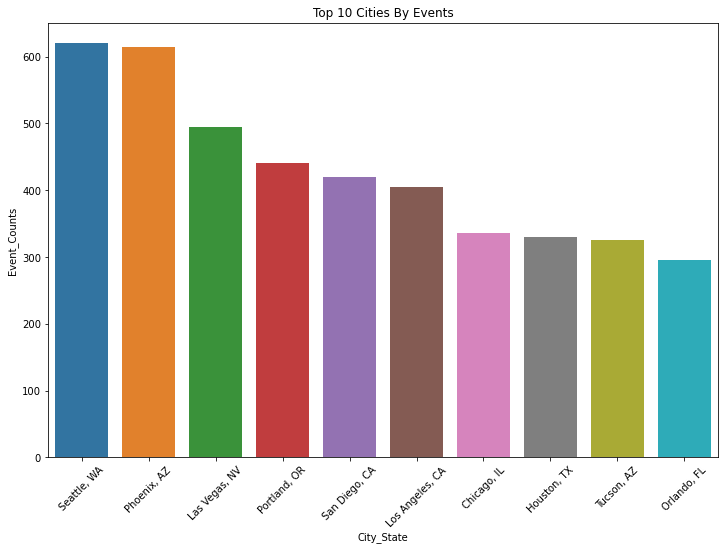

In [45]:
#Seaborn bar chart for top 10 cities
plt.figure(figsize=(12,8))
ax = sns.barplot(x='City_State', y='Event_Counts', data=nuforc_events_city_state_counts)
plt.xticks(rotation='45')
plt.title('Top 10 Cities By Events')
plt.show()

In [46]:
#Top states by total NUFORC events reported
#Top 3 states were California, Florida, and Washington - all in western/southwestern states
nuforc_events_clean['State'].value_counts(dropna=False).head(51)

CA    12287
FL     5831
WA     5390
TX     4534
NY     4205
      ...  
DE      279
WY      278
SD      272
ND      179
DC      127
Name: State, Length: 51, dtype: int64

- **Seattle, WA topped the city chart.** 
- Seattle UFO sightings are **NOT due to space launches** in WA state (None; see above), and only N=7 in Alaska (AK)
- It is interesting to hypothesize that Seattle sightings are due to northern lights? See month ranges of WA sightings below. 279/620 of UFO sightings in Seattle, WA were in key months for seeing Northern Lights. 
- **i.e. more than half cannot be explained by Northern Lights alone.**

In [47]:
#Code checks for months of UFO sightings in Seattle and checks if they are in key months for Northern Lights in Washington State 10-03. 
Northern_months = [10, 11, 12, 1, 2, 3]
nuforc_events_clean[(nuforc_events_clean['City_State'] == 'Seattle, WA') & (pd.DatetimeIndex(nuforc_events_clean['Date']).month.isin(Northern_months))]

,Hour,Minute,City,State,Shape,Duration,Summary,Event_URL,Date,Converted_Duration_min,Date_Clean,Year,City_State
1068,6.0,43.0,Seattle,WA,Sphere,58 minutes,I have looked at...,http://www.nufor...,01/23/17,58.000000,2017-01-23,2017,"Seattle, WA"
1146,14.0,0.0,Seattle,WA,Rectangle,not sure,Two strange rect...,http://www.nufor...,01/14/17,0.000000,2017-01-14,2017,"Seattle, WA"
1838,18.0,30.0,Seattle,WA,Light,NaN,Blue lights over...,http://www.nufor...,11/15/16,0.000000,2016-11-15,2016,"Seattle, WA"
5923,17.0,0.0,Seattle,WA,NaN,1 hour,White lights in ...,http://www.nufor...,03/04/16,60.000000,2016-03-04,2016,"Seattle, WA"
6363,18.0,30.0,Seattle,WA,Triangle,30 minutes,Three triangular...,http://www.nufor...,02/05/16,30.000000,2016-02-05,2016,"Seattle, WA"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
100587,21.0,55.0,Seattle,WA,NaN,0.5 second,"Couple sees ""met...",http://www.nufor...,01/03/95,0.000000,1995-01-03,1995,"Seattle, WA"
100620,1.0,39.0,Seattle,WA,Light,20 sec.,Man witnesses ve...,http://www.nufor...,12/24/94,0.333333,1994-12-24,1994,"Seattle, WA"
101786,0.0,0.0,Seattle,WA,Other,2 MIN,I and a witness ...,http://www.nufor...,01/01/92,0.000000,1992-01-01,1992,"Seattle, WA"
104120,17.0,0.0,Seattle,WA,Sphere,10 minutes,An orange ball o...,http://www.nufor...,01/13/83,10.000000,1983-01-13,1983,"Seattle, WA"


<AxesSubplot:title={'center':'Seattle UFO Sightings per Month'}, xlabel='Month', ylabel='Number of UFO Sightings'>

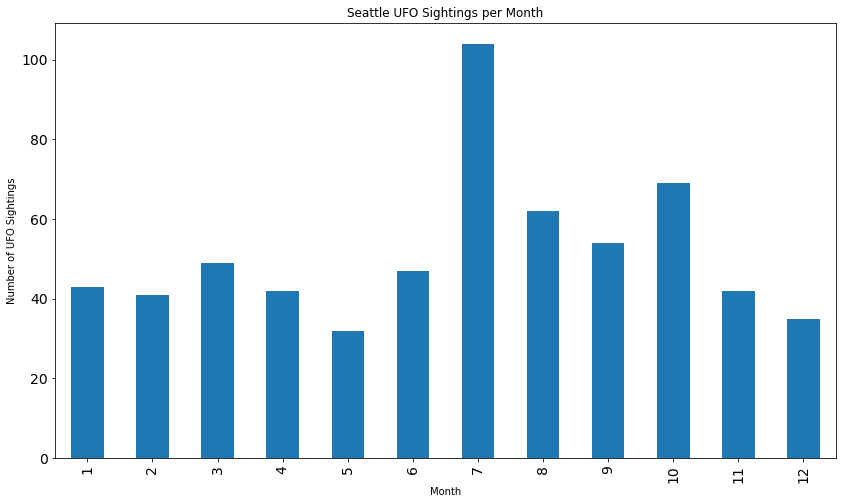

In [107]:
#Bargraph per month for Seattle, showing that aurora borealis (Northern Lights) are unlikely to explain UFO sightings.
nuforc_Seattle_datetime = pd.to_datetime(nuforc_events_clean[nuforc_events_clean['City_State'] == 'Seattle, WA']['Date'])
nuforc_Seattle_months = nuforc_Seattle_datetime.dt.month
nuforc_Seattle_months.head()
nuforc_Seattle_months.value_counts().sort_index().plot.bar(figsize = (14,8), title = "Seattle UFO Sightings per Month", fontsize=14, xlabel = "Month", ylabel = "Number of UFO Sightings")

In [49]:
#Creating new dataframe to look at counts by state
nuforc_events_state_counts = nuforc_events_clean['State'].value_counts().reset_index().head(10)
nuforc_events_state_counts.columns = ['State','Event_Counts']

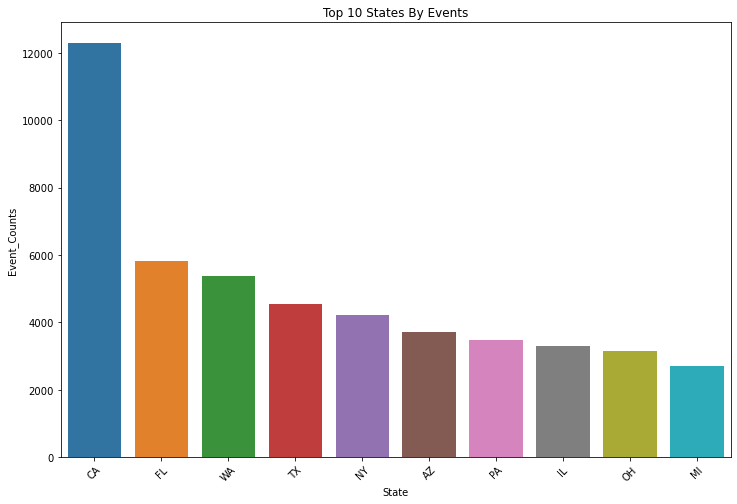

In [106]:
#Seaborn bar chart for top 10 states
plt.figure(figsize=(12,8))
ax = sns.barplot(x='State', y='Event_Counts', data=nuforc_events_state_counts)
plt.xticks(rotation='45')
plt.title('Top 10 States By Events')
plt.show()

#### Geographic Variance

In [51]:
#All unique states and provinces in scope - only including 50 U.S. states plus W
nuforc_events_clean['State'].unique()

array(['NJ', 'IL', 'AL', 'CO', 'SC', 'GA', 'MO', 'AR', 'NE', 'MS', 'OH',
       'KY', 'RI', 'WI', 'PA', 'NM', 'CA', 'NY', 'MI', 'LA', 'TX', 'IN',
       'AZ', 'DE', 'WA', 'NV', 'UT', 'OR', 'ME', 'HI', 'ID', 'OK', 'VA',
       'NH', 'FL', 'KS', 'MA', 'IA', 'NC', 'TN', 'SD', 'MD', 'MN', 'MT',
       'WV', 'CT', 'AK', 'ND', 'WY', 'VT', 'DC'], dtype=object)

In [52]:
#Function to group states into regions, per Census reference map: https://www2.census.gov/geo/pdfs/maps-data/maps/reference/us_regdiv.pdf
def state_regions(value):
    if value in ('IL','OH','MI','WI','IN','MO','MN','IA','KS','NE','SD','ND'):
        return 'Midwest'

    elif value in ('NY','PA','NJ','MA','CT','ME','NH','RI','VT'):
        return 'Northeast'

    elif value in ('TN','KY','AL','MS','FL','NC','VA','GA','SC','MD','WV','DE','DC','TX','OK','LA','AR'):
        return 'South'    
    
    elif value in ('AZ','CO','NV','NM','UT','ID','MT','WY','CA','WA','OR','AK','HI'):
        return 'West'
    
    else:
        return 'Outside U.S.'
    
nuforc_events_clean['Region'] = nuforc_events_clean['State'].map(state_regions)


#Function to group states into sub-regions, per Census reference map: https://www2.census.gov/geo/pdfs/maps-data/maps/reference/us_regdiv.pdf
def state_sub_regions(value):
    if value in ('IL','OH','MI','WI','IN'):
        return 'East North Central'

    elif value in ('MO','MN','IA','KS','NE','SD','ND'):
        return 'West North Central'

    elif value in ('NY','PA','NJ'):
        return 'Mid Atlantic'    
    
    elif value in ('MA','CT','ME','NH','RI','VT'):
        return 'New England'

    elif value in ('TN','KY','AL','MS'):
        return 'East South Central'

    elif value in ('FL','NC','VA','GA','SC','MD','WV','DE','DC'):
        return 'South Atlantic'

    elif value in ('TX','OK','LA','AR'):
        return 'West South Central'

    elif value in ('AZ','CO','NV','NM','UT','ID','MT','WY'):
        return 'Mountain'

    elif value in ('CA','WA','OR','AK','HI'):
        return 'Pacific'    
    
    else:
        return 'Outside U.S.'
    
nuforc_events_clean['Sub-Region'] = nuforc_events_clean['State'].map(state_sub_regions)
display(nuforc_events_clean.head())

,Hour,Minute,City,State,Shape,Duration,Summary,Event_URL,Date,Converted_Duration_min,Date_Clean,Year,City_State,Region,Sub-Region
0,14.0,15.0,Palmyra,NJ,Other,5 minutes,I observed an ai...,http://www.nufor...,04/20/17,5.000000,2017-04-20,2017,"Palmyra, NJ",Northeast,Mid Atlantic
1,4.0,56.0,Bridgeview,IL,Light,20 seconds,"Bridgeview, IL, ...",http://www.nufor...,04/20/17,0.333333,2017-04-20,2017,"Bridgeview, IL",Midwest,East North Central
2,23.0,55.0,Newton,AL,Triangle,5 seconds,Silent triangle ...,http://www.nufor...,04/19/17,0.083333,2017-04-19,2017,"Newton, AL",South,East South Central
3,23.0,50.0,Newton,AL,Triangle,5-6 minutes,My friend and I ...,http://www.nufor...,04/19/17,0.000000,2017-04-19,2017,"Newton, AL",South,East South Central
4,23.0,29.0,Denver,CO,Light,1 hour,Moved slow but m...,http://www.nufor...,04/19/17,60.000000,2017-04-19,2017,"Denver, CO",West,Mountain


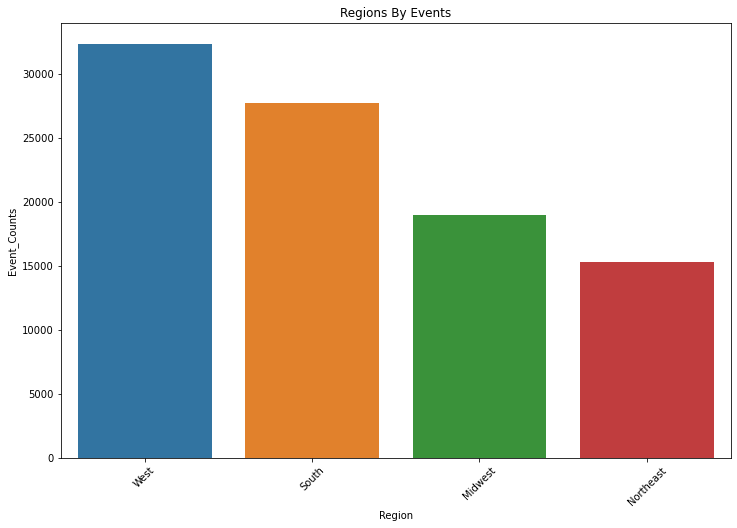

In [53]:
#Region counts
nuforc_events_region_counts = nuforc_events_clean['Region'].value_counts(dropna=False).reset_index()
nuforc_events_region_counts.columns = ['Region','Event_Counts']
nuforc_events_region_counts

# #Seaborn bar chart for events by region
plt.figure(figsize=(12,8))
ax = sns.barplot(x='Region', y='Event_Counts', data=nuforc_events_region_counts)
plt.xticks(rotation='45')
plt.title('Regions By Events')
plt.show()

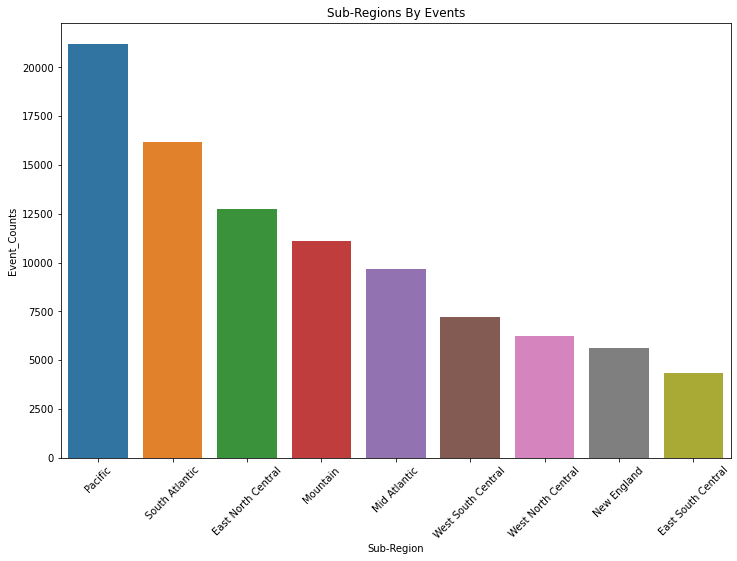

In [54]:
#Region counts
nuforc_events_sub_region_counts = nuforc_events_clean['Sub-Region'].value_counts(dropna=False).reset_index()
nuforc_events_sub_region_counts.columns = ['Sub-Region','Event_Counts']
nuforc_events_sub_region_counts

# #Seaborn bar chart for events by region
plt.figure(figsize=(12,8))
ax = sns.barplot(x='Sub-Region', y='Event_Counts', data=nuforc_events_sub_region_counts)
plt.xticks(rotation='45')
plt.title('Sub-Regions By Events')
plt.show()

### Questions - Explaining regional effects in UFO Sighting Counts (SN 11/29/2022)

- FL sightings are #2 in frequency, and this state is #1 in space launches (see space_launch_data['State'].value_counts() repeated below. Bar graph not plotted for brevity of analysis.

In [55]:
space_launch_data_clean['State'].value_counts()

FL    257
CA     81
TX     23
VA     23
NM     18
AK      7
HI      2
Name: State, dtype: int64

### Heatmaps of Incidents

##### By State - 2000-2020

In [56]:
nuforc_heatmap = nuforc_events_clean[['City_State', 'State','Year']].value_counts().reset_index()
nuforc_heatmap.columns = ['City_State','State','Year','Events']
nuforc_heatmap.sort_values(by='Events', ascending=False).head()

,City_State,State,Year,Events
0,"Tinley Park, IL",IL,2004,92
1,"Portland, OR",OR,2014,47
2,"Las Vegas, NV",NV,2012,45
3,"Myrtle Beach, SC",SC,2014,45
4,"Phoenix, AZ",AZ,2005,45


##### Heatmap By City - Decades

In [57]:
heatmap_1970s = nuforc_heatmap[(nuforc_heatmap['Year'] >= 1970) & (nuforc_heatmap['Year'] <= 1979)].reset_index(drop=True)
heatmap_1970s = heatmap_1970s.rename({'Events': '1970s'}, axis=1)

heatmap_1980s = nuforc_heatmap[(nuforc_heatmap['Year'] >= 1980) & (nuforc_heatmap['Year'] <= 1989)].reset_index(drop=True)
heatmap_1980s = heatmap_1980s.rename({'Events': '1980s'}, axis=1)

heatmap_1990s = nuforc_heatmap[(nuforc_heatmap['Year'] >= 1990) & (nuforc_heatmap['Year'] <= 1999)].reset_index(drop=True)
heatmap_1990s = heatmap_1990s.rename({'Events': '1990s'}, axis=1)

heatmap_2000s = nuforc_heatmap[(nuforc_heatmap['Year'] >= 2000) & (nuforc_heatmap['Year'] <= 2009)].reset_index(drop=True)
heatmap_2000s = heatmap_2000s.rename({'Events': '2000s'}, axis=1)

heatmap_2010s = nuforc_heatmap[(nuforc_heatmap['Year'] >= 2010) & (nuforc_heatmap['Year'] <= 2019)].reset_index(drop=True)
heatmap_2010s = heatmap_2010s.rename({'Events': '2010s'}, axis=1)

heatmap_2020s = nuforc_heatmap[(nuforc_heatmap['Year'] >= 2020) & (nuforc_heatmap['Year'] <= 2022)].reset_index(drop=True)
heatmap_2020s = heatmap_2020s.rename({'Events': '2020s'}, axis=1)


In [58]:
heatmap_1970s_groupby = heatmap_1970s[['1970s','City_State']].groupby('City_State').agg(sum)
heatmap_1980s_groupby = heatmap_1980s[['1980s','City_State']].groupby('City_State').agg(sum)
heatmap_1990s_groupby = heatmap_1990s[['1990s','City_State']].groupby('City_State').agg(sum)
heatmap_2000s_groupby = heatmap_2000s[['2000s','City_State']].groupby('City_State').agg(sum)
heatmap_2010s_groupby = heatmap_2010s[['2010s','City_State']].groupby('City_State').agg(sum)
heatmap_2020s_groupby = heatmap_2020s[['2020s','City_State']].groupby('City_State').agg(sum)

merge_70s_80s = pd.merge(heatmap_1970s_groupby, heatmap_1980s_groupby, on ='City_State', how ='left')
merge_80s_90s = pd.merge(merge_70s_80s, heatmap_1990s_groupby, on = 'City_State', how = 'left')
merge_90s_00s = pd.merge(merge_80s_90s, heatmap_2000s_groupby, on = 'City_State', how = 'left')
merge_00s_10s = pd.merge(merge_90s_00s, heatmap_2010s_groupby, on = 'City_State', how = 'left')
merge_10s_20s = pd.merge(merge_00s_10s, heatmap_2020s_groupby, on = 'City_State', how = 'left')


merge_10s_20s['Sum_Events'] = merge_10s_20s.sum(axis=1)
final_heatmap_cities_decades = merge_10s_20s.replace(np.nan,0)

final_heatmap_cities_decades = final_heatmap_cities_decades.astype({'1980s': 'int','1990s': 'int',
                                                                   '2000s': 'int','2010s': 'int',
                                                                   '2020s': 'int','Sum_Events': 'int'})

final_heatmap_cities_decades.sort_values(by='Sum_Events',ascending=False)
final_heatmap_cities_decades_top_10 = final_heatmap_cities_decades.sort_values(by='Sum_Events',ascending=False).head(10)

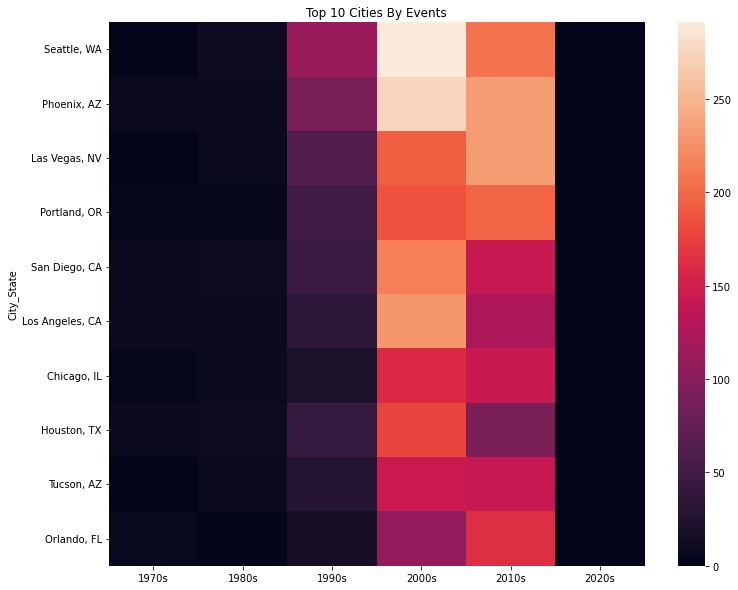

In [59]:
final_heatmap_cities_decades_top_10.drop(['Sum_Events'], axis=1, inplace=True)
plt.figure(figsize=(12,10))
ax = sns.heatmap(final_heatmap_cities_decades_top_10)
plt.title('Top 10 Cities By Events')
plt.show()

##### Heatmap By City - 2000-2019

In [60]:
heatmap_2000 = nuforc_heatmap[(nuforc_heatmap['Year'] == 2000)].reset_index(drop=True)
heatmap_2000 = heatmap_2000.rename({'Events': '2000'}, axis=1)

heatmap_2001 = nuforc_heatmap[(nuforc_heatmap['Year'] == 2001)].reset_index(drop=True)
heatmap_2001 = heatmap_2001.rename({'Events': '2001'}, axis=1)

heatmap_2002 = nuforc_heatmap[(nuforc_heatmap['Year'] == 2002)].reset_index(drop=True)
heatmap_2002 = heatmap_2002.rename({'Events': '2002'}, axis=1)

heatmap_2003 = nuforc_heatmap[(nuforc_heatmap['Year'] == 2003)].reset_index(drop=True)
heatmap_2003 = heatmap_2003.rename({'Events': '2003'}, axis=1)

heatmap_2004 = nuforc_heatmap[(nuforc_heatmap['Year'] == 2004)].reset_index(drop=True)
heatmap_2004 = heatmap_2004.rename({'Events': '2004'}, axis=1)

heatmap_2005 = nuforc_heatmap[(nuforc_heatmap['Year'] == 2005)].reset_index(drop=True)
heatmap_2005 = heatmap_2005.rename({'Events': '2005'}, axis=1)

heatmap_2006 = nuforc_heatmap[(nuforc_heatmap['Year'] == 2006)].reset_index(drop=True)
heatmap_2006 = heatmap_2006.rename({'Events': '2006'}, axis=1)

heatmap_2007 = nuforc_heatmap[(nuforc_heatmap['Year'] == 2007)].reset_index(drop=True)
heatmap_2007 = heatmap_2007.rename({'Events': '2007'}, axis=1)

heatmap_2008 = nuforc_heatmap[(nuforc_heatmap['Year'] == 2008)].reset_index(drop=True)
heatmap_2008 = heatmap_2008.rename({'Events': '2008'}, axis=1)

heatmap_2009 = nuforc_heatmap[(nuforc_heatmap['Year'] == 2009)].reset_index(drop=True)
heatmap_2009 = heatmap_2009.rename({'Events': '2009'}, axis=1)

heatmap_2010 = nuforc_heatmap[(nuforc_heatmap['Year'] == 2010)].reset_index(drop=True)
heatmap_2010 = heatmap_2010.rename({'Events': '2010'}, axis=1)

heatmap_2011 = nuforc_heatmap[(nuforc_heatmap['Year'] == 2011)].reset_index(drop=True)
heatmap_2011 = heatmap_2011.rename({'Events': '2011'}, axis=1)

heatmap_2012 = nuforc_heatmap[(nuforc_heatmap['Year'] == 2012)].reset_index(drop=True)
heatmap_2012 = heatmap_2012.rename({'Events': '2012'}, axis=1)

heatmap_2013 = nuforc_heatmap[(nuforc_heatmap['Year'] == 2013)].reset_index(drop=True)
heatmap_2013 = heatmap_2013.rename({'Events': '2013'}, axis=1)

heatmap_2014 = nuforc_heatmap[(nuforc_heatmap['Year'] == 2014)].reset_index(drop=True)
heatmap_2014 = heatmap_2014.rename({'Events': '2014'}, axis=1)

heatmap_2015 = nuforc_heatmap[(nuforc_heatmap['Year'] == 2015)].reset_index(drop=True)
heatmap_2015 = heatmap_2015.rename({'Events': '2015'}, axis=1)

heatmap_2016 = nuforc_heatmap[(nuforc_heatmap['Year'] == 2016)].reset_index(drop=True)
heatmap_2016 = heatmap_2016.rename({'Events': '2016'}, axis=1)

heatmap_2017 = nuforc_heatmap[(nuforc_heatmap['Year'] == 2017)].reset_index(drop=True)
heatmap_2017 = heatmap_2017.rename({'Events': '2017'}, axis=1)

heatmap_2018 = nuforc_heatmap[(nuforc_heatmap['Year'] == 2018)].reset_index(drop=True)
heatmap_2018 = heatmap_2018.rename({'Events': '2018'}, axis=1)

heatmap_2019 = nuforc_heatmap[(nuforc_heatmap['Year'] == 2019)].reset_index(drop=True)
heatmap_2019 = heatmap_2019.rename({'Events': '2019'}, axis=1)



In [61]:
heatmap_2000_groupby = heatmap_2000[['2000','City_State']].groupby('City_State').agg(sum)
heatmap_2001_groupby = heatmap_2001[['2001','City_State']].groupby('City_State').agg(sum)
heatmap_2002_groupby = heatmap_2002[['2002','City_State']].groupby('City_State').agg(sum)
heatmap_2003_groupby = heatmap_2003[['2003','City_State']].groupby('City_State').agg(sum)
heatmap_2004_groupby = heatmap_2004[['2004','City_State']].groupby('City_State').agg(sum)
heatmap_2005_groupby = heatmap_2005[['2005','City_State']].groupby('City_State').agg(sum)
heatmap_2006_groupby = heatmap_2006[['2006','City_State']].groupby('City_State').agg(sum)
heatmap_2007_groupby = heatmap_2007[['2007','City_State']].groupby('City_State').agg(sum)
heatmap_2008_groupby = heatmap_2008[['2008','City_State']].groupby('City_State').agg(sum)
heatmap_2009_groupby = heatmap_2009[['2009','City_State']].groupby('City_State').agg(sum)
heatmap_2010_groupby = heatmap_2010[['2010','City_State']].groupby('City_State').agg(sum)
heatmap_2011_groupby = heatmap_2011[['2011','City_State']].groupby('City_State').agg(sum)
heatmap_2012_groupby = heatmap_2012[['2012','City_State']].groupby('City_State').agg(sum)
heatmap_2013_groupby = heatmap_2013[['2013','City_State']].groupby('City_State').agg(sum)
heatmap_2014_groupby = heatmap_2014[['2014','City_State']].groupby('City_State').agg(sum)
heatmap_2015_groupby = heatmap_2015[['2015','City_State']].groupby('City_State').agg(sum)
heatmap_2016_groupby = heatmap_2016[['2016','City_State']].groupby('City_State').agg(sum)
heatmap_2017_groupby = heatmap_2017[['2017','City_State']].groupby('City_State').agg(sum)
heatmap_2018_groupby = heatmap_2018[['2018','City_State']].groupby('City_State').agg(sum)
heatmap_2019_groupby = heatmap_2019[['2019','City_State']].groupby('City_State').agg(sum)

merge_00_01 = pd.merge(heatmap_2000_groupby, heatmap_2001_groupby, on ='City_State', how ='left')
merge_01_02 = pd.merge(merge_00_01, heatmap_2002_groupby, on ='City_State', how ='left')
merge_02_03 = pd.merge(merge_01_02, heatmap_2003_groupby, on ='City_State', how ='left')
merge_03_04 = pd.merge(merge_02_03, heatmap_2004_groupby, on ='City_State', how ='left')
merge_04_05 = pd.merge(merge_03_04, heatmap_2005_groupby, on ='City_State', how ='left')
merge_05_06 = pd.merge(merge_04_05, heatmap_2006_groupby, on ='City_State', how ='left')
merge_06_07 = pd.merge(merge_05_06, heatmap_2007_groupby, on ='City_State', how ='left')
merge_07_08 = pd.merge(merge_06_07, heatmap_2008_groupby, on ='City_State', how ='left')
merge_08_09 = pd.merge(merge_07_08, heatmap_2009_groupby, on ='City_State', how ='left')
merge_09_10 = pd.merge(merge_08_09, heatmap_2010_groupby, on ='City_State', how ='left')
merge_10_11 = pd.merge(merge_09_10, heatmap_2011_groupby, on ='City_State', how ='left')
merge_11_12 = pd.merge(merge_10_11, heatmap_2012_groupby, on ='City_State', how ='left')
merge_12_13 = pd.merge(merge_11_12, heatmap_2013_groupby, on ='City_State', how ='left')
merge_13_14 = pd.merge(merge_12_13, heatmap_2014_groupby, on ='City_State', how ='left')
merge_14_15 = pd.merge(merge_13_14, heatmap_2015_groupby, on ='City_State', how ='left')
merge_15_16 = pd.merge(merge_14_15, heatmap_2016_groupby, on ='City_State', how ='left')
merge_16_17 = pd.merge(merge_15_16, heatmap_2017_groupby, on ='City_State', how ='left')
merge_17_18 = pd.merge(merge_16_17, heatmap_2018_groupby, on ='City_State', how ='left')
merge_18_19 = pd.merge(merge_17_18, heatmap_2019_groupby, on ='City_State', how ='left')

merge_18_19['Sum_Events'] = merge_18_19.sum(axis=1)
final_heatmap_cities_years = merge_18_19.replace(np.nan,0)

final_heatmap_cities_years = final_heatmap_cities_years.astype({'2000': 'int','2001': 'int','2002': 'int','2003': 'int',
                                                                '2004': 'int','2005': 'int','2006': 'int','2007': 'int',
                                                                '2008': 'int','2009': 'int','2010': 'int','2011': 'int',
                                                                '2012': 'int','2013': 'int','2014': 'int','2015': 'int',
                                                                '2016': 'int','2017': 'int','2018': 'int','2019': 'int',
                                                                'Sum_Events': 'int',})

final_heatmap_cities_years.sort_values(by='Sum_Events',ascending=False)
final_heatmap_cities_years_top_10 = final_heatmap_cities_years.sort_values(by='Sum_Events',ascending=False).head(10)


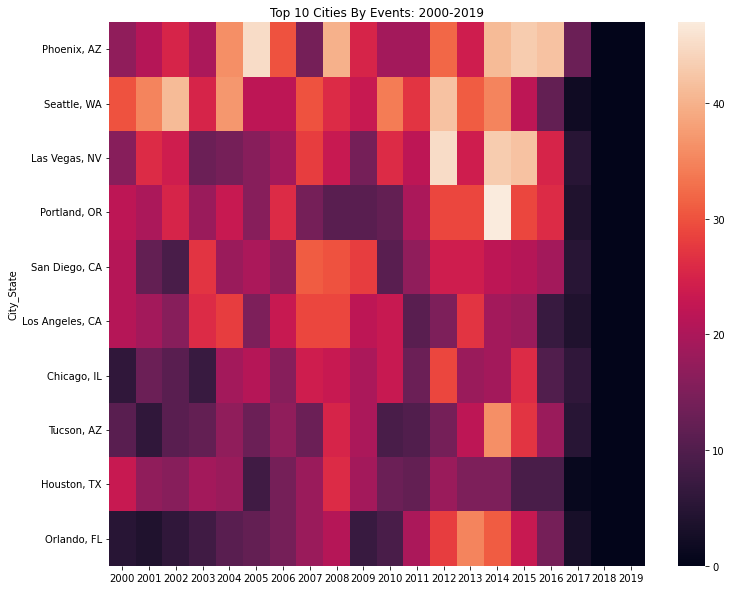

In [62]:
final_heatmap_cities_years_top_10.drop(['Sum_Events'], axis=1, inplace=True)
plt.figure(figsize=(12,10))
ax = sns.heatmap(final_heatmap_cities_years_top_10)
plt.title('Top 10 Cities By Events: 2000-2019')
plt.show()

##### Heatmap By State - Decades

In [63]:
heatmap_1970s_groupby_states = heatmap_1970s[['1970s','State']].groupby('State').agg(sum)
heatmap_1980s_groupby_states = heatmap_1980s[['1980s','State']].groupby('State').agg(sum)
heatmap_1990s_groupby_states = heatmap_1990s[['1990s','State']].groupby('State').agg(sum)
heatmap_2000s_groupby_states = heatmap_2000s[['2000s','State']].groupby('State').agg(sum)
heatmap_2010s_groupby_states = heatmap_2010s[['2010s','State']].groupby('State').agg(sum)
heatmap_2020s_groupby_states = heatmap_2020s[['2020s','State']].groupby('State').agg(sum)

merge_70s_80s_states = pd.merge(heatmap_1970s_groupby_states, heatmap_1980s_groupby_states, on ='State', how ='left')
merge_80s_90s_states = pd.merge(merge_70s_80s_states, heatmap_1990s_groupby_states, on = 'State', how = 'left')
merge_90s_00s_states = pd.merge(merge_80s_90s_states, heatmap_2000s_groupby_states, on = 'State', how = 'left')
merge_00s_10s_states = pd.merge(merge_90s_00s_states, heatmap_2010s_groupby_states, on = 'State', how = 'left')
merge_10s_20s_states = pd.merge(merge_00s_10s_states, heatmap_2020s_groupby_states, on = 'State', how = 'left')


merge_10s_20s_states['Sum_Events'] = merge_10s_20s_states.sum(axis=1)
final_heatmap_states_decades = merge_10s_20s_states.replace(np.nan,0)

final_heatmap_states_decades = final_heatmap_states_decades.astype({'1980s': 'int','1990s': 'int',
                                                                   '2000s': 'int','2010s': 'int',
                                                                   '2020s': 'int','Sum_Events': 'int'})

final_heatmap_states_decades.sort_values(by='Sum_Events',ascending=False)
final_heatmap_states_decades_top_10 = final_heatmap_states_decades.sort_values(by='Sum_Events',ascending=False).head(10)

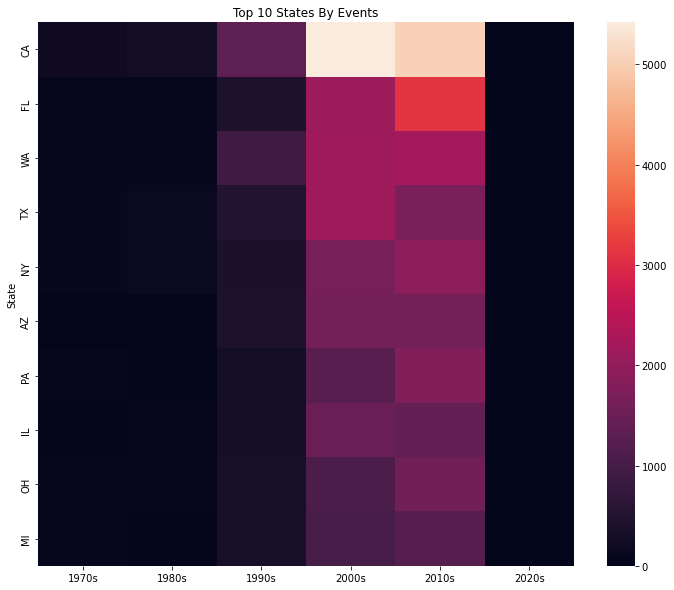

In [64]:
final_heatmap_states_decades_top_10.drop(['Sum_Events'], axis=1, inplace=True)
plt.figure(figsize=(12,10))
ax = sns.heatmap(final_heatmap_states_decades_top_10)
plt.title('Top 10 States By Events')
plt.show()

##### Heatmap By State - 2000-2019

In [65]:
heatmap_2000_state_groupby = heatmap_2000[['2000','State']].groupby('State').agg(sum)
heatmap_2001_state_groupby = heatmap_2001[['2001','State']].groupby('State').agg(sum)
heatmap_2002_state_groupby = heatmap_2002[['2002','State']].groupby('State').agg(sum)
heatmap_2003_state_groupby = heatmap_2003[['2003','State']].groupby('State').agg(sum)
heatmap_2004_state_groupby = heatmap_2004[['2004','State']].groupby('State').agg(sum)
heatmap_2005_state_groupby = heatmap_2005[['2005','State']].groupby('State').agg(sum)
heatmap_2006_state_groupby = heatmap_2006[['2006','State']].groupby('State').agg(sum)
heatmap_2007_state_groupby = heatmap_2007[['2007','State']].groupby('State').agg(sum)
heatmap_2008_state_groupby = heatmap_2008[['2008','State']].groupby('State').agg(sum)
heatmap_2009_state_groupby = heatmap_2009[['2009','State']].groupby('State').agg(sum)
heatmap_2010_state_groupby = heatmap_2010[['2010','State']].groupby('State').agg(sum)
heatmap_2011_state_groupby = heatmap_2011[['2011','State']].groupby('State').agg(sum)
heatmap_2012_state_groupby = heatmap_2012[['2012','State']].groupby('State').agg(sum)
heatmap_2013_state_groupby = heatmap_2013[['2013','State']].groupby('State').agg(sum)
heatmap_2014_state_groupby = heatmap_2014[['2014','State']].groupby('State').agg(sum)
heatmap_2015_state_groupby = heatmap_2015[['2015','State']].groupby('State').agg(sum)
heatmap_2016_state_groupby = heatmap_2016[['2016','State']].groupby('State').agg(sum)
heatmap_2017_state_groupby = heatmap_2017[['2017','State']].groupby('State').agg(sum)
heatmap_2018_state_groupby = heatmap_2018[['2018','State']].groupby('State').agg(sum)
heatmap_2019_state_groupby = heatmap_2019[['2019','State']].groupby('State').agg(sum)

merge_00_01_state = pd.merge(heatmap_2000_state_groupby, heatmap_2001_state_groupby, on ='State', how ='left')
merge_01_02_state = pd.merge(merge_00_01_state, heatmap_2002_state_groupby, on ='State', how ='left')
merge_02_03_state = pd.merge(merge_01_02_state, heatmap_2003_state_groupby, on ='State', how ='left')
merge_03_04_state = pd.merge(merge_02_03_state, heatmap_2004_state_groupby, on ='State', how ='left')
merge_04_05_state = pd.merge(merge_03_04_state, heatmap_2005_state_groupby, on ='State', how ='left')
merge_05_06_state = pd.merge(merge_04_05_state, heatmap_2006_state_groupby, on ='State', how ='left')
merge_06_07_state = pd.merge(merge_05_06_state, heatmap_2007_state_groupby, on ='State', how ='left')
merge_07_08_state = pd.merge(merge_06_07_state, heatmap_2008_state_groupby, on ='State', how ='left')
merge_08_09_state = pd.merge(merge_07_08_state, heatmap_2009_state_groupby, on ='State', how ='left')
merge_09_10_state = pd.merge(merge_08_09_state, heatmap_2010_state_groupby, on ='State', how ='left')
merge_10_11_state = pd.merge(merge_09_10_state, heatmap_2011_state_groupby, on ='State', how ='left')
merge_11_12_state = pd.merge(merge_10_11_state, heatmap_2012_state_groupby, on ='State', how ='left')
merge_12_13_state = pd.merge(merge_11_12_state, heatmap_2013_state_groupby, on ='State', how ='left')
merge_13_14_state = pd.merge(merge_12_13_state, heatmap_2014_state_groupby, on ='State', how ='left')
merge_14_15_state = pd.merge(merge_13_14_state, heatmap_2015_state_groupby, on ='State', how ='left')
merge_15_16_state = pd.merge(merge_14_15_state, heatmap_2016_state_groupby, on ='State', how ='left')
merge_16_17_state = pd.merge(merge_15_16_state, heatmap_2017_state_groupby, on ='State', how ='left')
merge_17_18_state = pd.merge(merge_16_17_state, heatmap_2018_state_groupby, on ='State', how ='left')
merge_18_19_state = pd.merge(merge_17_18_state, heatmap_2019_state_groupby, on ='State', how ='left')

merge_18_19_state['Sum_Events'] = merge_18_19_state.sum(axis=1)
final_heatmap_states_years = merge_18_19_state.replace(np.nan,0)

final_heatmap_states_years = final_heatmap_states_years.astype({'2000': 'int','2001': 'int','2002': 'int','2003': 'int',
                                                                '2004': 'int','2005': 'int','2006': 'int','2007': 'int',
                                                                '2008': 'int','2009': 'int','2010': 'int','2011': 'int',
                                                                '2012': 'int','2013': 'int','2014': 'int','2015': 'int',
                                                                '2016': 'int','2017': 'int','2018': 'int','2019': 'int',
                                                                'Sum_Events': 'int',})

final_heatmap_states_years.sort_values(by='Sum_Events',ascending=False)
final_heatmap_states_years_top_10 = final_heatmap_states_years.sort_values(by='Sum_Events',ascending=False).head(10)

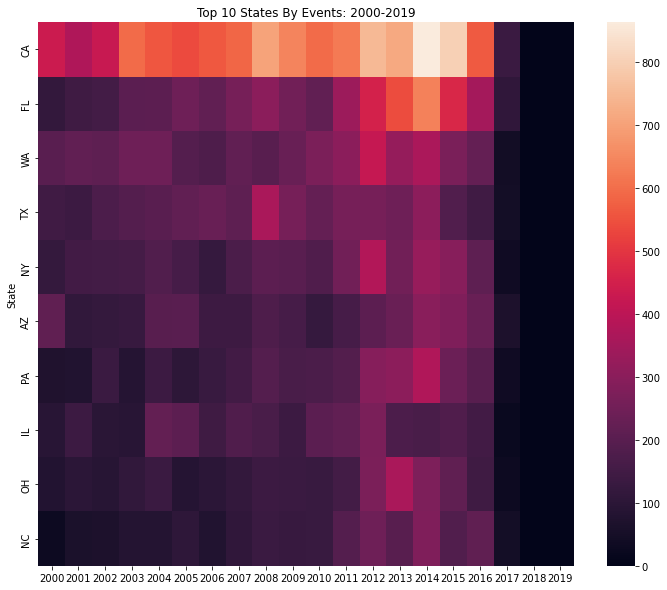

In [66]:
final_heatmap_states_years_top_10.drop(['Sum_Events'], axis=1, inplace=True)
plt.figure(figsize=(12,10))
ax = sns.heatmap(final_heatmap_states_years_top_10)
plt.title('Top 10 States By Events: 2000-2019')
plt.show()

### Relating the Proximity of UFO Sightings to plausible non-Alien events

- Proximity (Statewise, Citywise, Latitude/longitude) of UFO sightings to commercial space launches
    - 1522 UFO sightings were on the same day as commercial launches
    - 150 were in the same state. I.E. Only <10% of UFO sightings could be explained by Commercial space launches.

In [67]:
#For each data of UFO sighting, determine if there was a Commercial Space Launch that day 

new_UFO = nuforc_events_clean
new_UFO.rename(columns={'State': 'UFO_State'}, inplace=True)
new_launch = space_launch_data_clean
new_launch.rename(columns={'State': 'Launch_State'}, inplace=True)

UFO_launch = new_UFO[['Date', 'UFO_State']].merge(new_launch[['Date', 'Launch_State']], how='right')
UFO_launch = UFO_launch[~UFO_launch['UFO_State'].isna() & ~UFO_launch['Launch_State'].isna()]
UFO_launch


,Date,UFO_State,Launch_State
0,09/08/98,TX,CA
2,09/07/14,IA,FL
3,09/07/14,IL,FL
4,09/07/14,KS,FL
5,09/07/14,MI,FL
...,...,...,...
1746,04/12/03,MO,FL
1747,04/12/03,CA,FL
1748,04/12/03,OH,FL
1749,04/12/99,WA,FL


- Of these 1522, 150 were in the same state. In other words, the likelihood of UFO sightings being related to space launches is low (<10%)

In [68]:
UFO_launch_match = UFO_launch[UFO_launch['UFO_State'] == UFO_launch['Launch_State']]
UFO_launch_match

,Date,UFO_State,Launch_State
25,09/07/14,FL,FL
26,09/06/08,CA,CA
28,09/06/08,CA,CA
32,09/06/08,CA,CA
33,09/06/08,CA,CA
...,...,...,...
1734,04/14/08,FL,FL
1736,04/14/08,FL,FL
1741,04/12/03,FL,FL
1742,04/12/03,FL,FL


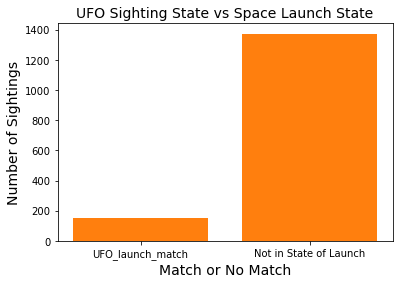

In [69]:
# Show a bar graph of Match between State of sightings and State of space launch.

plt.bar(['UFO_launch_match', 'Not in State of Launch'], [150, 1372])

plt.bar(['UFO_launch_match', 'Not in State of Launch'], [len(UFO_launch_match), len(UFO_launch) - len(UFO_launch_match)])
plt.title('UFO Sighting State vs Space Launch State', fontsize=14)
plt.xlabel("Match or No Match", fontsize=14)
plt.ylabel("Number of Sightings", fontsize=14)
pass

- **Proximity (Statewise, Citywise, Latitude/longitude) of UFO sightings to military bases**
    - As expected, because there is a military base in each State, there was a sighting in the same state as each base (94348 rows)
    - We now explored City, State Proximity
    - Found that a small minority (270/94348) UFO sightings were in the same city as a Military base city.
    - Assumption - that Site Name for Military base matches a city. This is a gross simplification, since a Military base city  often has a different name (e.g. Fort XXX but is close to a city. To reconcile this properly would require a dictionary of military bases and cities within a defined proximity. We elected not to go this level, although it is possible in future data exploration. 

In [70]:
new_UFO[new_UFO['UFO_State'].isin(military_bases_clean['State Terr'])]

,Hour,Minute,City,UFO_State,Shape,Duration,Summary,Event_URL,Date,Converted_Duration_min,Date_Clean,Year,City_State,Region,Sub-Region
0,14.0,15.0,Palmyra,NJ,Other,5 minutes,I observed an ai...,http://www.nufor...,04/20/17,5.000000,2017-04-20,2017,"Palmyra, NJ",Northeast,Mid Atlantic
1,4.0,56.0,Bridgeview,IL,Light,20 seconds,"Bridgeview, IL, ...",http://www.nufor...,04/20/17,0.333333,2017-04-20,2017,"Bridgeview, IL",Midwest,East North Central
2,23.0,55.0,Newton,AL,Triangle,5 seconds,Silent triangle ...,http://www.nufor...,04/19/17,0.083333,2017-04-19,2017,"Newton, AL",South,East South Central
3,23.0,50.0,Newton,AL,Triangle,5-6 minutes,My friend and I ...,http://www.nufor...,04/19/17,0.000000,2017-04-19,2017,"Newton, AL",South,East South Central
4,23.0,29.0,Denver,CO,Light,1 hour,Moved slow but m...,http://www.nufor...,04/19/17,60.000000,2017-04-19,2017,"Denver, CO",West,Mountain
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106880,19.0,0.0,Madison,ME,Oval,30 seconds,"Oval, Glowing Ch...",http://www.nufor...,01/18/74,0.500000,1974-01-18,1974,"Madison, ME",Northeast,New England
106882,5.0,0.0,Terre Haute,IN,Disk,20 min,UFO tampreing wi...,http://www.nufor...,01/15/74,20.000000,1974-01-15,1974,"Terre Haute, IN",Midwest,East North Central
106884,21.0,0.0,Carbondale,PA,Circle,three days,A circular objec...,http://www.nufor...,01/09/74,0.000000,1974-01-09,1974,"Carbondale, PA",Northeast,Mid Atlantic
106887,3.0,0.0,Brooklyn,TX,Circle,15 minutes,A large circular...,http://www.nufor...,01/01/74,15.000000,1974-01-01,1974,"Brooklyn, TX",South,West South Central


In [71]:
#First create City, State Column for Military bases. Assumption - Site Name for Military base matches a city.
#Often a Military base will have a different name but be close to a city

military_bases_clean['City_State'] = military_bases_clean['Site Name'] + ', ' + military_bases_clean['State Terr']
nuforc_events_clean[nuforc_events_clean['City_State'].isin(military_bases_clean['City_State'])]

,Hour,Minute,City,UFO_State,Shape,Duration,Summary,Event_URL,Date,Converted_Duration_min,Date_Clean,Year,City_State,Region,Sub-Region
60,0.0,38.0,Honolulu,HI,Circle,30 seconds,Saw a bright red...,http://www.nufor...,04/16/17,0.5,2017-04-16,2017,"Honolulu, HI",West,Pacific
764,22.0,0.0,National City,CA,Light,>5-10 minutes,Three lights flo...,http://www.nufor...,02/15/17,0.0,2017-02-15,2017,"National City, CA",West,Pacific
869,NaN,NaN,Youngstown,OH,Fireball,Ongoing,Looks like an as...,http://www.nufor...,02/09/17,0.0,2017-02-09,2017,"Youngstown, OH",Midwest,East North Central
936,20.0,0.0,Gambrills,MD,Light,1 hour,Seen a bright li...,http://www.nufor...,02/03/17,60.0,2017-02-03,2017,"Gambrills, MD",South,South Atlantic
952,22.0,15.0,Fort Leonard Wood,MO,Disk,1 minute,Driving N 15 mi....,http://www.nufor...,02/01/17,1.0,2017-02-01,2017,Fort Leonard Woo...,Midwest,West North Central
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106189,1.0,0.0,Cannon AFB,NM,Disk,Weeks,Air Force scramb...,http://www.nufor...,01/06/76,0.0,1976-01-06,1976,"Cannon AFB, NM",West,Mountain
106495,13.0,0.0,Youngstown,OH,Circle,about 5 minns,I was about 7 ( ...,http://www.nufor...,06/01/75,0.0,1975-06-01,1975,"Youngstown, OH",Midwest,East North Central
106577,1.0,0.0,Fort Polk,LA,Unknown,5 min,I witnessed this...,http://www.nufor...,12/01/74,5.0,1974-12-01,1974,"Fort Polk, LA",South,West South Central
106666,11.0,0.0,Holloman AFB,NM,Other,1 hour,Had my military ...,http://www.nufor...,08/21/74,60.0,1974-08-21,1974,"Holloman AFB, NM",West,Mountain


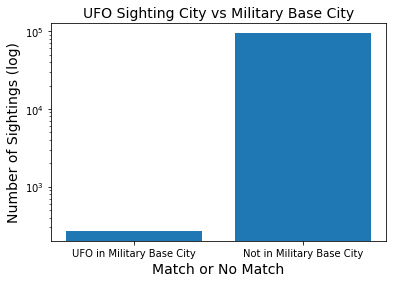

In [72]:
# Show Bar Graph of number of sightings in vs not in the same city as a military base.

plt.bar(['UFO in Military Base City', 'Not in Military Base City'], [270, 94078])

plt.title('UFO Sighting City vs Military Base City', fontsize=14)
plt.xlabel("Match or No Match", fontsize=14)
plt.yscale('log')
plt.ylabel("Number of Sightings (log)", fontsize=14)
pass

- **Proximity (Statewise, Citywise, Latitude/longitude) of UFO sightings to airport locations**
    - 36656 of the UFO sightings (about a third) occurred in Cities with an airport.
    - Assumption: We could not readily create a City, State Column for airports, since only City was given. 
    - To reconcile this would require creating a dictionary of IATA number and City_State. This was not done now, but could be done for a future exploration. 

In [73]:
# We could not readily create a City, State Column for airports, since only City was given. Assumption - that city is unique. 
# This is false since the same name can be given to different cities. To reconcile this would require creating a dictionary of IATA number and City_State.
# This was not done now, but could be done for a future exploration. 

nuforc_events_clean[nuforc_events_clean['City'].isin(airports_clean['City'])]

,Hour,Minute,City,UFO_State,Shape,Duration,Summary,Event_URL,Date,Converted_Duration_min,Date_Clean,Year,City_State,Region,Sub-Region
2,23.0,55.0,Newton,AL,Triangle,5 seconds,Silent triangle ...,http://www.nufor...,04/19/17,0.083333,2017-04-19,2017,"Newton, AL",South,East South Central
3,23.0,50.0,Newton,AL,Triangle,5-6 minutes,My friend and I ...,http://www.nufor...,04/19/17,0.000000,2017-04-19,2017,"Newton, AL",South,East South Central
4,23.0,29.0,Denver,CO,Light,1 hour,Moved slow but m...,http://www.nufor...,04/19/17,60.000000,2017-04-19,2017,"Denver, CO",West,Mountain
6,20.0,50.0,Garden City,SC,Sphere,20 seconds,Five bright oran...,http://www.nufor...,04/19/17,0.333333,2017-04-19,2017,"Garden City, SC",South,South Atlantic
7,20.0,50.0,North Myrtle Beach,SC,Light,1 minute,Orange Orbs Spot...,http://www.nufor...,04/19/17,1.000000,2017-04-19,2017,North Myrtle Bea...,South,South Atlantic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106867,22.0,30.0,Santa Rosa,CA,Disk,2 hours,The size of the ...,http://www.nufor...,03/15/74,120.000000,1974-03-15,1974,"Santa Rosa, CA",West,Pacific
106872,3.0,0.0,Indianapolis,IN,Disk,5 seconds,rapid moving hig...,http://www.nufor...,02/19/74,0.083333,1974-02-19,1974,"Indianapolis, IN",Midwest,East North Central
106877,23.0,0.0,San Diego,CA,Unknown,10 seconds,Something very l...,http://www.nufor...,01/30/74,0.166667,1974-01-30,1974,"San Diego, CA",West,Pacific
106880,19.0,0.0,Madison,ME,Oval,30 seconds,"Oval, Glowing Ch...",http://www.nufor...,01/18/74,0.500000,1974-01-18,1974,"Madison, ME",Northeast,New England


## *Priority B Questions*

### NUFORC events reported years

#### Time Series of Reported UFO Sightings Over Years - All Reported Events

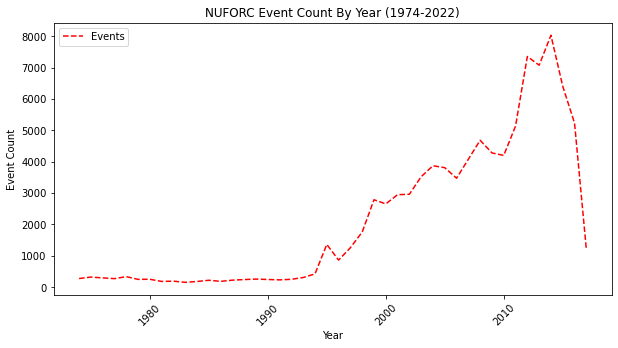

In [74]:
#Creating new dataframe with only columns that we'll need
nuforc_time = nuforc_events_clean[['Date_Clean', 'Year']].value_counts().reset_index()
nuforc_time.columns = ['Date','Year','Event_Count']

#Filtering out data after 2022 (start at 1974)
nuforc_time = nuforc_time[(nuforc_time['Year'] <= 2022) & (nuforc_time['Year'] >= 1974)].reset_index(drop=True)

#Sum up contribution amounts by candidate
nuforc_time_groupby = nuforc_time[['Event_Count','Year']].groupby('Year').agg(sum)

#Sizing plot
plt.figure(figsize=(10,5))

#Create line to depict change in event counts by year
plt.plot(nuforc_time_groupby.Event_Count, color = 'red', linestyle = '--', label = 'Events')
plt.xticks(rotation=45)

#Adding in the axis labels and title:
plt.xlabel('Year')
plt.ylabel('Event Count')
plt.title('NUFORC Event Count By Year (1974-2022)')

#Adding in legend
plt.legend(loc = 'upper left')

#Display plot
plt.show()

#### Max, Min, Median, Mean, Outlier Events By Year

In [75]:
nuforc_time_groupby.describe()

,Event_Count
count,44.000000
mean,2144.272727
std,2324.983695
min,156.000000
25%,252.500000
50%,1038.000000
75%,3827.000000
max,8033.000000


In [76]:
#The year with the most NUFORC reported events was 2014 (referenced with above .describe())
nuforc_time_groupby[nuforc_time_groupby['Event_Count'] >= 8033]

,Event_Count
Year,
2014,8033


In [77]:
#The year with the least NUFORC reported events was 1983 (referenced with above .describe())
nuforc_time_groupby[nuforc_time_groupby['Event_Count'] <= 156]

,Event_Count
Year,
1983,156


In [78]:
#Outlier years by number of reported NUFORC events (defining 'outlier' as above 90th percentile and below 10th percentile of total events by year)

#10th percentile
print('The 10th percentile value is:', nuforc_time_groupby['Event_Count'].quantile(0.1)) 

#90th percentile
print('The 90th percentile value is:', nuforc_time_groupby['Event_Count'].quantile(0.9))

print('\n')

#Printing out the outlier years
nuforc_time_groupby[(nuforc_time_groupby['Event_Count'] <= 202.4) | (nuforc_time_groupby['Event_Count'] >= 5204.5)].sort_values(by='Event_Count')

The 10th percentile value is: 202.4
The 90th percentile value is: 5204.5




,Event_Count
Year,
1983,156
1984,184
1981,185
1986,187
1982,194
2016,5233
2015,6408
2013,7078
2012,7356


#### Change By State Year Over Year

In [79]:
#Creating new dataframe with only columns that we'll need
nuforc_state_YoY = nuforc_events_clean[['UFO_State', 'Year']].value_counts().reset_index()
nuforc_state_YoY.columns = ['UFO_State','Year','Event_Count']

#Filtering out data after 2022 (start at 1974)
nuforc_state_YoY = nuforc_state_YoY[(nuforc_state_YoY['Year'] <= 2022) & (nuforc_state_YoY['Year'] >= 1974) & 
                                    ((nuforc_state_YoY['UFO_State'] == 'CA') | (nuforc_state_YoY['UFO_State'] == 'FL') |
                                    (nuforc_state_YoY['UFO_State'] == 'WA') | (nuforc_state_YoY['UFO_State'] == 'TX') |
                                    (nuforc_state_YoY['UFO_State'] == 'NY') | (nuforc_state_YoY['UFO_State'] == 'AZ') |
                                    (nuforc_state_YoY['UFO_State'] == 'PA') | (nuforc_state_YoY['UFO_State'] == 'IL') |
                                    (nuforc_state_YoY['UFO_State'] == 'OH') | (nuforc_state_YoY['UFO_State'] == 'MI'))].reset_index(drop=True)



In [80]:
#Create separate dataframes for each of the top 10 states by total reported NUFORC events

nuforc_ca = nuforc_state_YoY[nuforc_state_YoY['UFO_State'] == 'CA'].reset_index(drop=True)
nuforc_ca = nuforc_ca.rename({'Event_Count': 'CA'}, axis=1)
nuforc_ca.drop(['UFO_State'], axis=1, inplace=True)

nuforc_fl = nuforc_state_YoY[nuforc_state_YoY['UFO_State'] == 'FL'].reset_index(drop=True)
nuforc_fl = nuforc_fl.rename({'Event_Count': 'FL'}, axis=1)
nuforc_fl.drop(['UFO_State'], axis=1, inplace=True)

nuforc_wa = nuforc_state_YoY[nuforc_state_YoY['UFO_State'] == 'WA'].reset_index(drop=True)
nuforc_wa = nuforc_wa.rename({'Event_Count': 'WA'}, axis=1)
nuforc_wa.drop(['UFO_State'], axis=1, inplace=True)

nuforc_tx = nuforc_state_YoY[nuforc_state_YoY['UFO_State'] == 'TX'].reset_index(drop=True)
nuforc_tx = nuforc_tx.rename({'Event_Count': 'TX'}, axis=1)
nuforc_tx.drop(['UFO_State'], axis=1, inplace=True)

nuforc_ny = nuforc_state_YoY[nuforc_state_YoY['UFO_State'] == 'NY'].reset_index(drop=True)
nuforc_ny = nuforc_ny.rename({'Event_Count': 'NY'}, axis=1)
nuforc_ny.drop(['UFO_State'], axis=1, inplace=True)

nuforc_az = nuforc_state_YoY[nuforc_state_YoY['UFO_State'] == 'AZ'].reset_index(drop=True)
nuforc_az = nuforc_az.rename({'Event_Count': 'AZ'}, axis=1)
nuforc_az.drop(['UFO_State'], axis=1, inplace=True)

nuforc_pa = nuforc_state_YoY[nuforc_state_YoY['UFO_State'] == 'PA'].reset_index(drop=True)
nuforc_pa = nuforc_pa.rename({'Event_Count': 'PA'}, axis=1)
nuforc_pa.drop(['UFO_State'], axis=1, inplace=True)

nuforc_il = nuforc_state_YoY[nuforc_state_YoY['UFO_State'] == 'IL'].reset_index(drop=True)
nuforc_il = nuforc_il.rename({'Event_Count': 'IL'}, axis=1)
nuforc_il.drop(['UFO_State'], axis=1, inplace=True)

nuforc_oh = nuforc_state_YoY[nuforc_state_YoY['UFO_State'] == 'OH'].reset_index(drop=True)
nuforc_oh = nuforc_oh.rename({'Event_Count': 'OH'}, axis=1)
nuforc_oh.drop(['UFO_State'], axis=1, inplace=True)

nuforc_mi = nuforc_state_YoY[nuforc_state_YoY['UFO_State'] == 'MI'].reset_index(drop=True)
nuforc_mi = nuforc_mi.rename({'Event_Count': 'MI'}, axis=1)
nuforc_mi.drop(['UFO_State'], axis=1, inplace=True)

In [81]:
#Merge all the state dataframes into one dataframe that has a column of event counts for each state by year

merge_ca_fl_state = pd.merge(nuforc_ca, nuforc_fl, on ='Year', how ='left')
merge_fl_wa_state = pd.merge(merge_ca_fl_state, nuforc_wa, on ='Year', how ='left')
merge_wa_tx_state = pd.merge(merge_fl_wa_state, nuforc_tx, on ='Year', how ='left')
merge_tx_ny_state = pd.merge(merge_wa_tx_state, nuforc_ny, on ='Year', how ='left')
merge_ny_az_state = pd.merge(merge_tx_ny_state, nuforc_az, on ='Year', how ='left')
merge_az_pa_state = pd.merge(merge_ny_az_state, nuforc_pa, on ='Year', how ='left')
merge_pa_il_state = pd.merge(merge_az_pa_state, nuforc_il, on ='Year', how ='left')
merge_il_oh_state = pd.merge(merge_pa_il_state, nuforc_oh, on ='Year', how ='left')
merge_oh_mi_state = pd.merge(merge_il_oh_state, nuforc_mi, on ='Year', how ='left')

final_state_merge = merge_oh_mi_state.replace(np.nan,0)
final_state_merge.head()

,Year,CA,FL,WA,TX,NY,AZ,PA,IL,OH,MI
0,2014,864,635,366,307,325,300,378,168,277,182
1,2015,801,466,268,183,294,279,239,182,213,182
2,2012,752,454,421,261,379,209,292,269,273,233
3,2013,716,541,321,245,251,233,306,173,362,182
4,2008,704,301,199,365,209,178,190,167,136,140


### NUFORC events reported shapes

#### Count by shape type

In [83]:
#Looking at all possible event shapes reported in the NUFORC events data
nuforc_events_clean['Shape'].unique()

array(['Other', 'Light', 'Triangle', 'Sphere', 'Circle', nan, 'Changing',
       'Oval', 'Unknown', 'Cross', 'Formation', 'Teardrop', 'Cigar',
       'Fireball', 'Flash', 'Egg', 'Diamond', 'Disk', 'Chevron',
       'Rectangle', 'Cylinder', 'Cone', 'Hexagon', 'Flare', 'Crescent',
       'Delta', 'Pyramid', 'Round', 'Changed', 'Dome'], dtype=object)

In [84]:
#Creating new dataframe to only look at events where a legitimate shape was reported
nuforc_shapes = nuforc_events_clean[(nuforc_events_clean['Shape'] != 'Unknown') & (nuforc_events_clean['Shape'] != 'Other')
                                   & (nuforc_events_clean['Shape'] != 'Light') & (nuforc_events_clean['Shape'] != 'Changing')
                                   & (nuforc_events_clean['Shape'] != 'Formation') & (nuforc_events_clean['Shape'] != 'Flash')
                                   & (nuforc_events_clean['Shape'] != 'Changed')]


#Creating new dataframe to look at the top 10 shapes by total counts
nuforc_shapes_final = nuforc_shapes['Shape'].value_counts().reset_index().head(10)
nuforc_shapes_final.columns = ['Shape','Count']

#There were 10 distinct legitimate shapes reported
nuforc_shapes_final['Shape'].unique()

array(['Circle', 'Triangle', 'Fireball', 'Sphere', 'Disk', 'Oval',
       'Cigar', 'Rectangle', 'Cylinder', 'Diamond'], dtype=object)

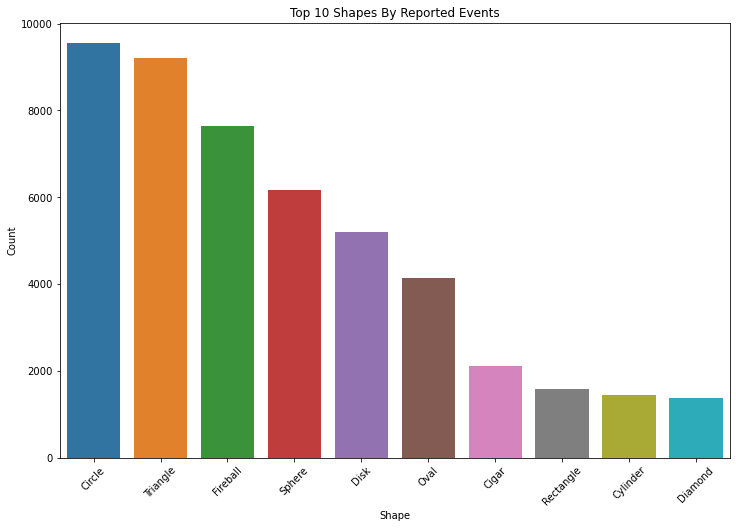

In [85]:
#Seaborn bar chart for top 10 shapes
plt.figure(figsize=(12,8))
ax = sns.barplot(x='Shape', y='Count', data=nuforc_shapes_final)
plt.xticks(rotation='45')
plt.title('Top 10 Shapes By Reported Events')
plt.show()

#### Frequency of each shape by state

In [86]:
def state_shapes(dataframe):
    """Function that will generate the top 5 shapes by event count by state"""
    
    dataframe = dataframe[['UFO_State', 'Shape']].value_counts().reset_index()
    
    dataframe.columns = ['UFO_State','Shape','Count']

    dataframe_groupby = dataframe[['Count','Shape']].groupby('Shape').agg(sum)

    return dataframe_groupby.sort_values(by='Count',ascending=False).head()

In [87]:
#Dataframe to look at top 5 states by NUFORC event count
most_popular_states = nuforc_events_clean[(nuforc_events_clean['UFO_State'] == 'CA') | (nuforc_events_clean['UFO_State'] == 'FL')
                                         | (nuforc_events_clean['UFO_State'] == 'WA') | (nuforc_events_clean['UFO_State'] == 'TX')
                                         | (nuforc_events_clean['UFO_State'] == 'NY')]

pd.set_option('display.max_rows', 500)

#Create groupby for state
by_state = most_popular_states.groupby(most_popular_states.UFO_State)

#Use .apply to break out top 5 shapes by popular state
by_state.apply(state_shapes)

Count
UFO_State Shape          
CA        Light      2530
          Circle     1208
          Triangle   1069
          Fireball   1012
          Other       860
FL        Light      1096
          Circle      651
          Fireball    642
          Triangle    506
          Unknown     415
NY        Light       826
          Circle      481
          Triangle    402
          Fireball    336
          Other       277
TX        Light       913
          Triangle    480
          Circle      418
          Other       369
          Unknown     363
WA        Light      1159
          Fireball    469
          Circle      465
          Triangle    439
          Unknown     419

### NUFORC events reported time / day

#### Frequency of reports by time of day

In [88]:
#Creating new dataframe, filtering out rows that have NaNs for hour and minute fields
time_fix = nuforc_events_clean.dropna(subset=['Hour','Minute'])

#Converting hours and minutes to ints
time_fix['Hour'] = time_fix['Hour'].astype(int)
time_fix['Minute'] = time_fix['Minute'].astype(int)

/var/folders/4k/wd6ck4v52l9bs1s6jc9y1r7r0000gn/T/ipykernel_50438/1043428674.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  time_fix['Hour'] = time_fix['Hour'].astype(int)
/var/folders/4k/wd6ck4v52l9bs1s6jc9y1r7r0000gn/T/ipykernel_50438/1043428674.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  time_fix['Minute'] = time_fix['Minute'].astype(int)


In [89]:
#Creating function that will allocate an A.M. or P.M. value based on the army time ('Hour' field) given in the NUFORC data 
def am_pm(value):
    if value >= 0 and value <= 12:
        return 'A.M.'   
    else:
        return 'P.M.'


#Apply AM_PM function to create a new column    
time_fix['AM_PM'] = time_fix['Hour'].map(am_pm)


#Create hour dictionary to convert army time to standard time equivalent, then apply dictionary replacement function
hour_dict = {0:12, 1:1, 2:2, 3:3, 4:4, 5:5, 6:6, 7:7, 8:8, 9:9, 10:10, 11:11,
            12:12, 13:1, 14:2, 15:3, 16:4, 17:5, 18:6, 19:7, 20:8, 21:9, 22:10, 23:11}

time_fix['Hour'] = time_fix['Hour'].replace(hour_dict)

#Create minute dictionary to account for single digit minutes, then apply dictionary replacement function
minute_dict = {0:'00', 1:'01', 2:'02', 3:'03', 4:'04', 5:'05', 6:'06', 7:'07', 8:'08', 9:'09'}

time_fix['Minute'] = time_fix['Minute'].replace(minute_dict)

#New column with the cleaned up time field
time_fix['Full_Time'] = time_fix['Hour'].astype(str) + ':' + time_fix['Minute'].astype(str) + ' ' + time_fix['AM_PM']
time_fix.head()

/var/folders/4k/wd6ck4v52l9bs1s6jc9y1r7r0000gn/T/ipykernel_50438/2667486334.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  time_fix['AM_PM'] = time_fix['Hour'].map(am_pm)
/var/folders/4k/wd6ck4v52l9bs1s6jc9y1r7r0000gn/T/ipykernel_50438/2667486334.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  time_fix['Hour'] = time_fix['Hour'].replace(hour_dict)
/var/folders/4k/wd6ck4v52l9bs1s6jc9y1r7r0000gn/T/ipykernel_50438/2667486334.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a 

,Hour,Minute,City,UFO_State,Shape,Duration,Summary,Event_URL,Date,Converted_Duration_min,Date_Clean,Year,City_State,Region,Sub-Region,AM_PM,Full_Time
0,2,15,Palmyra,NJ,Other,5 minutes,I observed an ai...,http://www.nufor...,04/20/17,5.000000,2017-04-20,2017,"Palmyra, NJ",Northeast,Mid Atlantic,P.M.,2:15 P.M.
1,4,56,Bridgeview,IL,Light,20 seconds,"Bridgeview, IL, ...",http://www.nufor...,04/20/17,0.333333,2017-04-20,2017,"Bridgeview, IL",Midwest,East North Central,A.M.,4:56 A.M.
2,11,55,Newton,AL,Triangle,5 seconds,Silent triangle ...,http://www.nufor...,04/19/17,0.083333,2017-04-19,2017,"Newton, AL",South,East South Central,P.M.,11:55 P.M.
3,11,50,Newton,AL,Triangle,5-6 minutes,My friend and I ...,http://www.nufor...,04/19/17,0.000000,2017-04-19,2017,"Newton, AL",South,East South Central,P.M.,11:50 P.M.
4,11,29,Denver,CO,Light,1 hour,Moved slow but m...,http://www.nufor...,04/19/17,60.000000,2017-04-19,2017,"Denver, CO",West,Mountain,P.M.,11:29 P.M.


In [102]:
#New dataframe for 10 most popular times of day by event count
time_full = time_fix['Full_Time'].value_counts().reset_index().head(10)
time_full.columns = ['Time','Count']

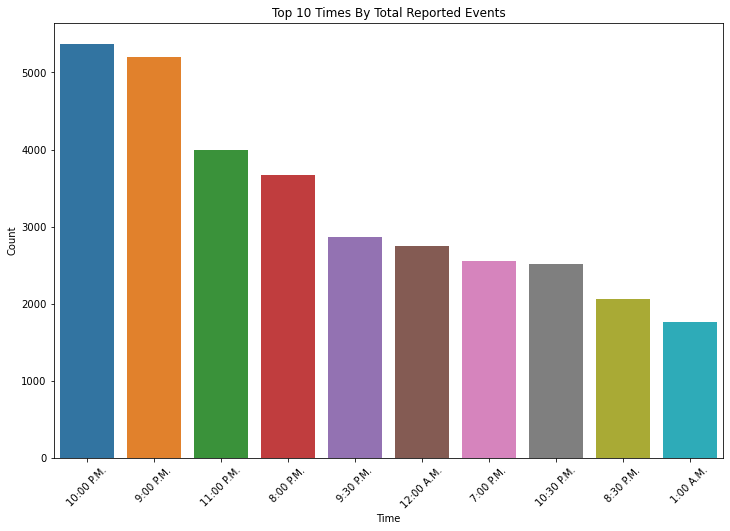

In [91]:
#Seaborn bar chart for top 10 reported NUFORC event times
plt.figure(figsize=(12,8))
ax = sns.barplot(x='Time', y='Count', data=time_full)
plt.xticks(rotation='45')
plt.title('Top 10 Times By Total Reported Events')
plt.show()

#### Frequency of reports by day of the week

In [92]:
#New dataframe - only pull records that have non-NaN values - print number of records before and after change
print(nuforc_events_clean.shape)
day_of_week = nuforc_events_clean.dropna(subset=['Date_Clean'],axis=0)
print(day_of_week.shape)

(94348, 15)
(94348, 15)


In [93]:
#Use day_name() function to convert the event day to the weekday it was reported on
day_of_week['Weekday'] = pd.to_datetime(day_of_week['Date_Clean'])
day_of_week['Weekday'] = day_of_week['Weekday'].dt.day_name()


In [94]:
#New dataframe to check counts of events by weekday
day_check = day_of_week['Weekday'].value_counts().reset_index()
day_check.columns = ['Day','Count']

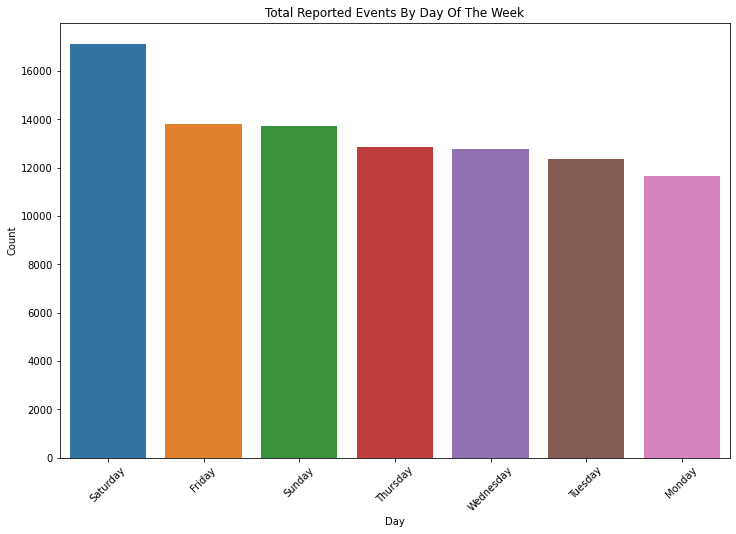

In [95]:
#Seaborn bar chart NUFORC event counts by day of the week
plt.figure(figsize=(12,8))
ax = sns.barplot(x='Day', y='Count', data=day_check)
plt.xticks(rotation='45')
plt.title('Total Reported Events By Day Of The Week')
plt.show()

### NUFORC Events Duration



**Duration Assumptions** 
- The initial assumption for duration is that we will only use cells where we have data that is in a (number, time) format for the duration type. 
- All time formats will be converted to minutes to simplify analysis.
- Duration cells in the following formats will be filtered out of our analysis:
    - ranges of numbers
    - text ranges
    - dscription of time
    - approximate time events
- During analysis, we will remove any cells that are:
    1) NAN
    2) Less than or euqal to 0
**dded to overall assumptions above.**

<AxesSubplot:title={'center':'Histogram of NUFORC Event Durations'}, xlabel='Duration (min)', ylabel='Counts'>

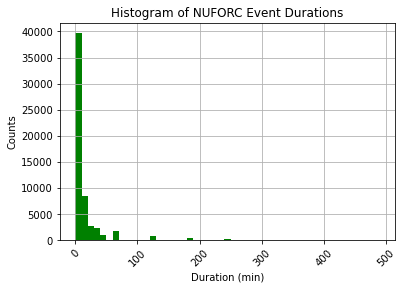

In [105]:
### NUFORC Events Duration

# We will filter out NAN events and events <= 0 (since time cannot be negative)

import matplotlib.pyplot as plt

nuforc_cleaned_duration = nuforc_events_clean[['Duration','Converted_Duration_min', 'UFO_State','Shape', 'Region']].where((nuforc_events_clean['Converted_Duration_min'] > 0)).dropna()

#Check if null filtered out
#pd.DataFrame(nuforc_cleaned_duration['Converted_Duration_min'].isnull() == False).value_counts()

nuforc_cleaned_duration['Converted_Duration_min'].describe()

ax = nuforc_cleaned_duration['Converted_Duration_min'].hist(bins=[i*10 for i in range(0,50)],color='green')
plt.xticks(rotation='45')
plt.title("Histogram of NUFORC Event Durations")
plt.xlabel("Duration (min)")
plt.ylabel("Counts")
ax

Text(0, 0.5, 'Counts')

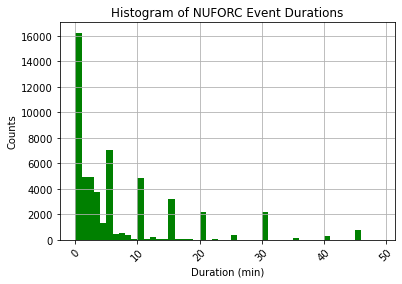

In [104]:
# Histogram dive with 1-min interval bins

ax = nuforc_cleaned_duration['Converted_Duration_min'].hist(bins=[i*1 for i in range(0,50)],color='green')
plt.xticks(rotation='45')
plt.title("Histogram of NUFORC Event Durations")
plt.xlabel("Duration (min)")
plt.ylabel("Counts")

In [98]:
nuforc_cleaned_duration['Converted_Duration_min'].describe()

count    57882.000000
mean        20.616254
std        310.027836
min          0.016667
25%          0.500000
50%          3.000000
75%         10.000000
max      43200.000000
Name: Converted_Duration_min, dtype: float64

<Figure size 864x576 with 0 Axes>

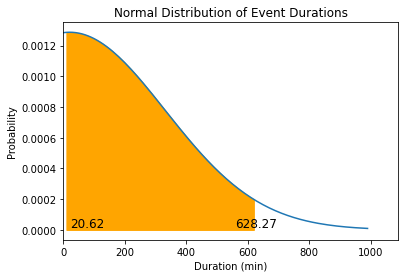

<Figure size 864x576 with 0 Axes>

In [112]:
import statistics
from scipy.stats import norm
from scipy import stats

x_axis = np.arange(-1000, 1000, 10)
mean = nuforc_cleaned_duration['Converted_Duration_min'].describe()[['mean']].reset_index().iloc[0][1]
stdev = nuforc_cleaned_duration['Converted_Duration_min'].describe()[['std']].reset_index().iloc[0][1]

pdf = stats.norm.pdf(x_axis, mean, stdev)
plt.plot(x_axis, norm.pdf(x_axis, mean, stdev))
plt.xlim(0)
std_lim = 1.96
low  = round(mean-std_lim*stdev,2)
high = round(mean+std_lim*stdev,2)

plt.fill_between(x_axis, pdf, where=(x_axis > 0) & (x_axis < high),color="orange")
plt.text(mean, 0, round(mean,2), ha='left',fontsize=12,va='bottom',color='black')
plt.text(high, 0, high, ha='center',fontsize=12,va='bottom',color="black")
plt.title("Normal Distribution of Event Durations")
plt.xlabel("Duration (min)")
plt.ylabel("Probability")
plt.figure(figsize=(12,8))

**Comments on Duration Analysis**

- The average NUFORC event lasted approximately 20.6 min with a standard deviation of 310 min (~5 hours). That's a large range of distributions. The longest reported UFO sighting lasted approximately 43,200 min (~720 hours / 30 days) - which could be an input error or an outlier. The shortest sighting lasted 0 min (instant). It seems that the majority of sightings are very short in duration.
- To explore this further, we created a Normal Distribution of Event Durations to assess the range where the majority of events fall. From the chart of normal distributions we can see that the average is 20.6 min, and 95% of all events fall between -587.04 min and 628.27 min. We've already filtered out all negative events during our analysis since time cannot be negative, so this chart is not indicating that there are negative sightings. Most sightings are less than 10.47 hours, with the majority being just under an hour. 
- We also created a histogram of NUFORC event durations to analyze the distribution of observations. We chose 50 bins at 10-minute intervals to display the data. 
- If we dive deeper into the data and create a histogram with 50 bins of 1-minute intervals to display the data, we can see that a major proportion of the reported events fall under within a minute. There are also spikes at every 5 minute interval - possibly people rounding numbers up or down when reporting the events.